## Extending the Analysis to Additional Visual Features

We extend our analysis beyond facial expressions to other visual attributes \( T \), including **image brightness** and **facial sadness (frown)**. Using the same counterfactual prediction framework, we generate paired images that differ only in the targeted feature and compute feature-specific counterfactual shifts in outlet likelihoods. This extension allows us to assess whether visual polarization patterns persist across multiple dimensions of visual presentation, and to evaluate the robustness and generality of our framework beyond smiles alone.

### Visual Feature T: Brightness

In [ ]:
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image, UnidentifiedImageError
import requests
from io import BytesIO
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from tqdm import tqdm
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import os
import matplotlib.pyplot as plt
import gensim
from gensim import corpora
from torchvision import models
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import numpy as np
from facenet_pytorch import InceptionResnetV1, MTCNN

torch.backends.cudnn.benchmark = True

class MultiHeadAttention(nn.Module):
    def __init__(self, embed_size, heads):
        super(MultiHeadAttention, self).__init__()
        self.embed_size = embed_size
        self.heads = heads
        self.head_dim = embed_size // heads
        assert self.head_dim * heads == embed_size
        self.values = nn.Linear(embed_size, embed_size, bias=False)
        self.keys = nn.Linear(embed_size, embed_size, bias=False)
        self.queries = nn.Linear(embed_size, embed_size, bias=False)
        self.fc_out = nn.Linear(embed_size, embed_size)

    def forward(self, values, keys, query):
        N = query.shape[0]
        value_len, key_len, query_len = values.shape[1], keys.shape[1], query.shape[1]
        values = self.values(values)
        keys = self.keys(keys)
        queries = self.queries(query)
        values = values.reshape(N, value_len, self.heads, self.head_dim)
        keys = keys.reshape(N, key_len, self.heads, self.head_dim)
        queries = queries.reshape(N, query_len, self.heads, self.head_dim)
        energy = torch.einsum("nqhd,nkhd->nhqk", [queries, keys])
        attention = torch.nn.functional.softmax(energy / (self.embed_size ** (1 / 2)), dim=3)
        out = torch.einsum("nhql,nlhd->nqhd", [attention, values]).reshape(
            N, query_len, self.heads * self.head_dim
        )
        out = self.fc_out(out)
        return out


class ImprovedMultiModalModel(nn.Module):
    def __init__(self, num_person_categories, num_party_categories, num_topics, num_classes,
                 num_date_categories, embedding_dim_person=8, embedding_dim_party=2,
                 embedding_dim_date=4, num_attention_heads=8, window_size=32):
        super(ImprovedMultiModalModel, self).__init__()
        self.face_vgg = InceptionResnetV1(pretrained='vggface2').eval()
        for param in list(self.face_vgg.parameters())[:-5]:
            param.requires_grad = False
        self.fc_vgg_1 = nn.Linear(512, 256)
        self.bn_vgg = nn.BatchNorm1d(256)
        self.dropout_vgg = nn.Dropout(0.3)
        self.person_embedding = nn.Embedding(num_person_categories, embedding_dim_person)
        self.party_embedding = nn.Embedding(num_party_categories, embedding_dim_party)
        self.date_embedding = nn.Embedding(num_date_categories, embedding_dim_date)
        self.fc_structured_proj = nn.Linear(
            embedding_dim_person + embedding_dim_party + num_topics + embedding_dim_date, 64
        )
        self.structured_attention = MultiHeadAttention(embed_size=64, heads=num_attention_heads)
        self.bn_structured = nn.BatchNorm1d(64)
        self.dropout_structured = nn.Dropout(0.4)
        self.fc_person_party_proj = nn.Linear(
            embedding_dim_person + embedding_dim_party, window_size
        )
        self.chunked_attention = MultiHeadAttention(embed_size=window_size, heads=num_attention_heads)
        resnet_pretrained = models.resnet101(pretrained=True)
        for param in list(resnet_pretrained.parameters())[:-10]:
            param.requires_grad = False
        self.features_resnet = nn.Sequential(*list(resnet_pretrained.children())[:-1])
        self.fc_resnet = nn.Linear(resnet_pretrained.fc.in_features, 512)
        self.bn_resnet = nn.BatchNorm1d(512)
        self.dropout_resnet = nn.Dropout(0.6)
        self.fc_out = nn.Linear(256 + 64 + 512, num_classes)
        self.dropout_out = nn.Dropout(0.5)

    def forward(self, resnet_img, face_img, person, party, topic_distribution, date):
        vgg_features = self.face_vgg(face_img)
        vgg_features = F.relu(self.bn_vgg(self.fc_vgg_1(vgg_features)))
        vgg_features = self.dropout_vgg(vgg_features)
        person_embedded = self.person_embedding(person)
        party_embedded = self.party_embedding(party)
        date_embedded = self.date_embedding(date)
        structured_data = torch.cat(
            (person_embedded, party_embedded, topic_distribution, date_embedded), dim=1
        )
        structured_data_proj = F.relu(self.fc_structured_proj(structured_data))
        structured_data = self.structured_attention(
            structured_data_proj.unsqueeze(1),
            structured_data_proj.unsqueeze(1),
            structured_data_proj.unsqueeze(1)
        ).squeeze(1)
        structured_data = F.relu(self.bn_structured(structured_data))
        structured_data = self.dropout_structured(structured_data)
        person_party_data = torch.cat((person_embedded, party_embedded), dim=1)
        person_party_proj = self.fc_person_party_proj(person_party_data).unsqueeze(1)
        vgg_chunks = vgg_features.view(vgg_features.size(0), 8, -1)
        attended_chunks = []
        for i in range(8):
            vgg_chunk = vgg_chunks[:, i, :].unsqueeze(1)
            attention_out = self.chunked_attention(
                person_party_proj, vgg_chunk, vgg_chunk
            ).squeeze(1)
            attended_chunks.append(attention_out)
        attended_vgg_features = torch.cat(attended_chunks, dim=1)
        resnet_features = self.features_resnet(resnet_img)
        resnet_features = torch.flatten(resnet_features, 1)
        resnet_features = F.relu(self.bn_resnet(self.fc_resnet(resnet_features)))
        resnet_features = self.dropout_resnet(resnet_features)
        combined_features = torch.cat(
            (attended_vgg_features, structured_data, resnet_features), dim=1
        )
        combined_features = self.dropout_out(combined_features)
        out = self.fc_out(combined_features)
        return out


df = pd.read_pickle('cleaned_complete_data_Face_Verification_Info_Raady_MLModel_Date.pkl')
df = df[df['dataset_type'] == 'val'].reset_index(drop=True)

unique_persons = df['Top1_Person'].nunique()
num_person_categories = unique_persons
num_party_categories = 2
num_topics = 40
num_date_features = len([col for col in df.columns if col.startswith('Date_')])
num_classes = len(df['News Center'].unique())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_attention_layers = 1

person_encoder = LabelEncoder()
party_encoder = LabelEncoder()
date_encoder = LabelEncoder()
outlet_encoder = LabelEncoder()

df['YearMonth'] = pd.to_datetime(df['Date_Pub'], errors='coerce').dt.to_period('M').astype(str)

person_encoder.fit(df['Top1_Person'])
party_encoder.fit(df['Real Person Side'])
date_encoder.fit(df['YearMonth'])
outlet_encoder.fit(df['News Center'])

df['person_encoded'] = person_encoder.transform(df['Top1_Person'])
df['party_encoded'] = party_encoder.transform(df['Real Person Side'])
df['date_encoded'] = date_encoder.transform(df['YearMonth'])
df['outlet_encoded'] = outlet_encoder.transform(df['News Center'])

num_person_categories = len(person_encoder.classes_)
num_party_categories = len(party_encoder.classes_)
num_date_categories = len(date_encoder.classes_)
num_classes = len(outlet_encoder.classes_)
num_topics = 40
embedding_dim_person = 8
embedding_dim_party = 2
embedding_dim_date = 4

model = ImprovedMultiModalModel(
    num_person_categories=num_person_categories,
    num_party_categories=num_party_categories,
    num_topics=num_topics,
    num_classes=num_classes,
    num_date_categories=num_date_categories,
    embedding_dim_person=embedding_dim_person,
    embedding_dim_party=embedding_dim_party,
    embedding_dim_date=embedding_dim_date,
    num_attention_heads=8
)

class AdaptedStaticImageDataset(Dataset):
    def __init__(self, dataframe, image_dir='data/Counterfactuals', transform=None, face_transform=None, smile=False, num_images=3):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
        self.face_transform = face_transform
        self.smile = smile
        self.num_images = num_images
        self.mtcnn = MTCNN(
            keep_all=False,
            device=torch.device('cpu'),
            thresholds=[0.4, 0.5, 0.6],
            min_face_size=15,
            factor=0.6
        )
        self.person_encoder = LabelEncoder()
        self.outlet_encoder = LabelEncoder()
        self.party_encoder = LabelEncoder()
        self.date_encoder = LabelEncoder()
        self.person_encoder.fit(dataframe['Top1_Person'])
        self.outlet_encoder.fit(dataframe['News Center'])
        self.party_encoder.fit(dataframe['Real Person Side'])
        self.date_encoder.fit(dataframe['YearMonth'])
        self.person_encoded = self.person_encoder.transform(dataframe['Top1_Person'])
        self.outlet_encoded = self.outlet_encoder.transform(dataframe['News Center'])
        self.party_encoded = self.party_encoder.transform(dataframe['Real Person Side'])
        self.dates = self.date_encoder.transform(dataframe['YearMonth'])
        self.topic_columns = [col for col in dataframe.columns if col.startswith('topic_')]

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        politician = self.dataframe.iloc[idx]['Top1_Person'].replace(' ', '_')
        img_suffix = '_with_bright' if self.smile else ''
        images = []
        face_images = []
        for i in range(1, self.num_images + 1):
            img_path = os.path.join(self.image_dir, f"{politician}{img_suffix}_{i}.jpg")
            try:
                img = Image.open(img_path).convert('RGB')
                face_img = self.mtcnn(img)
                if face_img is None:
                    face_img = transforms.Resize((224, 224))(img)
                    face_img = transforms.ToPILImage()(face_img)
                else:
                    face_img = transforms.Resize((224, 224))(face_img)
                    face_img = transforms.ToPILImage()(face_img)
                if self.transform:
                    img = self.transform(img)
                if self.face_transform:
                    face_img = self.face_transform(face_img)
                images.append(img)
                face_images.append(face_img)
            except (FileNotFoundError, UnidentifiedImageError):
                return self.__getitem__((idx + 1) % len(self.dataframe))
        label = self.outlet_encoded[idx]
        person = self.person_encoded[idx]
        party = self.party_encoded[idx]
        date = torch.tensor(self.dates[idx], dtype=torch.long)
        topic_distribution = self.dataframe.iloc[idx][self.topic_columns].values
        topic_distribution = np.array(topic_distribution, dtype=np.float32)
        topic_distribution = torch.tensor(topic_distribution)
        return images, face_images, torch.tensor(label, dtype=torch.long), torch.tensor(person, dtype=torch.long), torch.tensor(party, dtype=torch.long), topic_distribution, date


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.354, 0.225]),
])

face_transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_images = 3

batch_size = 32
num_workers = 30

adapted_dataset_without_smile = AdaptedStaticImageDataset(
    df, transform=transform, face_transform=face_transform, smile=False, num_images=3
)
adapted_loader_without_smile = DataLoader(
    adapted_dataset_without_smile, batch_size=batch_size, shuffle=False, num_workers=num_workers
)
adapted_dataset_with_smile = AdaptedStaticImageDataset(
    df, transform=transform, face_transform=face_transform, smile=True, num_images=3
)
adapted_loader_with_smile = DataLoader(
    adapted_dataset_with_smile, batch_size=batch_size, shuffle=False, num_workers=num_workers
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

def calculate_probabilities(static_loader, is_smile, model, device):
    prediction_probs = []
    model.eval()
    use_amp = torch.cuda.is_available()
    with torch.no_grad():
        for batch in tqdm(static_loader):
            images_list, face_images_list, label, person, party, topic_distribution, date = batch
            person = person.to(device)
            party = party.to(device)
            topic_distribution = topic_distribution.to(device)
            date = date.to(device)
            batch_results_per_view = []
            for i in range(len(images_list)):
                img = images_list[i].to(device)
                face_img = face_images_list[i].to(device)
                with torch.cuda.amp.autocast(enabled=use_amp):
                    output = model(img, face_img, person, party, topic_distribution, date)
                    probs = torch.softmax(output, dim=1)
                batch_results_per_view.append(probs.cpu().numpy())
            batch_probs_stacked = np.stack(batch_results_per_view, axis=1)
            for sample_probs in batch_probs_stacked:
                prediction_probs.append(sample_probs)
    return prediction_probs


for epoch in range(20, 21):
    print(f"Processing epoch {epoch}")
    checkpoint_path = f'model/model_checkpoint.pth'
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    model.to(device)

    prediction_probs_without_smile = calculate_probabilities(
        adapted_loader_without_smile, is_smile=False, model=model, device=device
    )
    prediction_probs_with_smile = calculate_probabilities(
        adapted_loader_with_smile, is_smile=True, model=model, device=device
    )

    class_names = adapted_dataset_without_smile.outlet_encoder.classes_
    prob_columns_without_smile = []
    prob_columns_with_smile = []

    for i in range(3):
        prob_without_smile = [
            np.squeeze(pred[i]) if pred is not None and len(pred) > i else None
            for pred in prediction_probs_without_smile
        ]
        prob_with_smile = [
            np.squeeze(pred[i]) if pred is not None and len(pred) > i else None
            for pred in prediction_probs_with_smile
        ]
        temp_df_without_smile = pd.DataFrame(
            prob_without_smile,
            columns=[f'prob_img{i+1}_{class_name}_without_smile' for class_name in class_names]
        )
        temp_df_with_smile = pd.DataFrame(
            prob_with_smile,
            columns=[f'prob_img{i+1}_{class_name}_with_smile' for class_name in class_names]
        )
        prob_columns_without_smile.append(temp_df_without_smile)
        prob_columns_with_smile.append(temp_df_with_smile)

    df_combined = pd.concat([df] + prob_columns_without_smile + prob_columns_with_smile, axis=1)
    reuters = 'www.reuters.com'
    final_ratios = {}
    final_diffs = {}

    for news_center in class_names:
        individual_ratios_list = []
        individual_diffs_list = []
        for i in range(1, 4):
            prob_news_center_with_smile_col = f'prob_img{i}_{news_center}_with_smile'
            prob_reuters_with_smile_col = f'prob_img{i}_{reuters}_with_smile'
            prob_news_center_without_smile_col = f'prob_img{i}_{news_center}_without_smile'
            prob_reuters_without_smile_col = f'prob_img{i}_{reuters}_without_smile'

            prob_news_center_with_smile = df_combined[prob_news_center_with_smile_col].values
            prob_reuters_with_smile = df_combined[prob_reuters_with_smile_col].values
            prob_news_center_without_smile = df_combined[prob_news_center_without_smile_col].values
            prob_reuters_without_smile = df_combined[prob_reuters_without_smile_col].values

            with np.errstate(divide='ignore', invalid='ignore'):
                factual_ratio = np.where(
                    prob_reuters_without_smile > 0,
                    prob_news_center_without_smile / prob_reuters_without_smile,
                    0
                )
                counterfactual_ratio = np.where(
                    prob_reuters_with_smile > 0,
                    prob_news_center_with_smile / prob_reuters_with_smile,
                    0
                )
                individual_ratios = np.where(
                    (factual_ratio > 0) & (counterfactual_ratio > 0),
                    np.log(counterfactual_ratio / factual_ratio),
                    0
                )
                individual_diff = np.where(
                    (prob_news_center_with_smile != None) &
                    (prob_news_center_without_smile != None),
                    prob_news_center_with_smile - prob_news_center_without_smile,
                    0
                )

            df_combined[f'Ratio_{i}_{news_center}'] = individual_ratios
            df_combined[f'Diff_{i}_{news_center}'] = individual_diff
            individual_ratios_list.append(individual_ratios)
            individual_diffs_list.append(individual_diff)

        mean_final_ratio = np.mean(individual_ratios_list, axis=0)
        mean_final_diff = np.mean(individual_diffs_list, axis=0)
        df_combined[f'Final_Ratio_{news_center}_epoch_{epoch}'] = mean_final_ratio
        df_combined[f'Final_Diff_{news_center}_epoch_{epoch}'] = mean_final_diff

    output_file = f'Final_CSV_For_Analysis_Brightness.csv'
    df_combined.to_csv(output_file, index=False)
    print(f"Final_Ratio and Final_Diff for epoch {epoch} have been calculated and saved to {output_file}.")

### Counterfactual Validation Using Brightness (Figure A.16)

Using counterfactual estimates generated by the **PMCIG algorithm** with respect to the visual feature \(T\) (image brightness), we evaluate how brightness-based visual slant aligns with existing **non-visual benchmarks of news media slant**. This analysis examines whether outlets exhibit systematic and consistent ideological positioning through brightness manipulation, and whether such patterns translate into visual slant and polarization comparable to those observed for facial expressions.

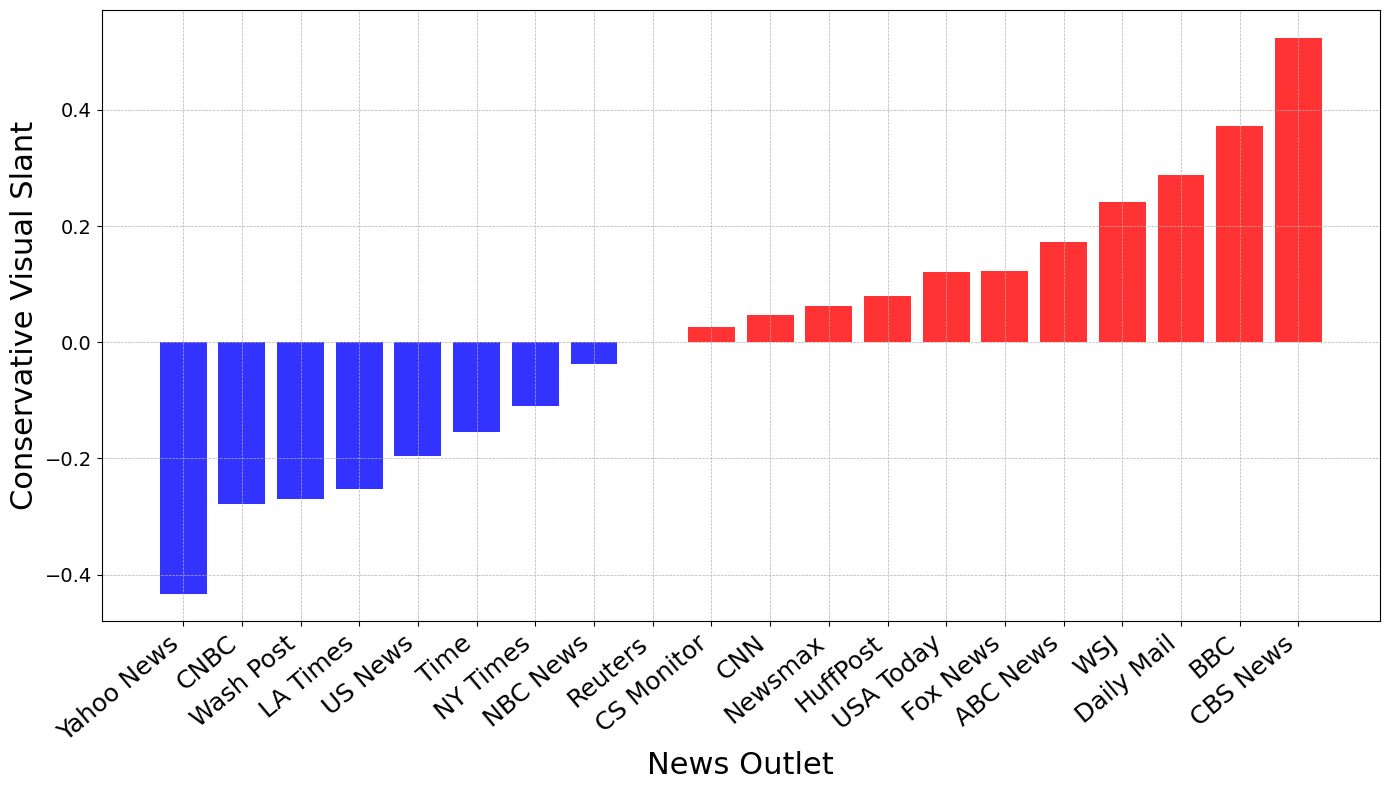

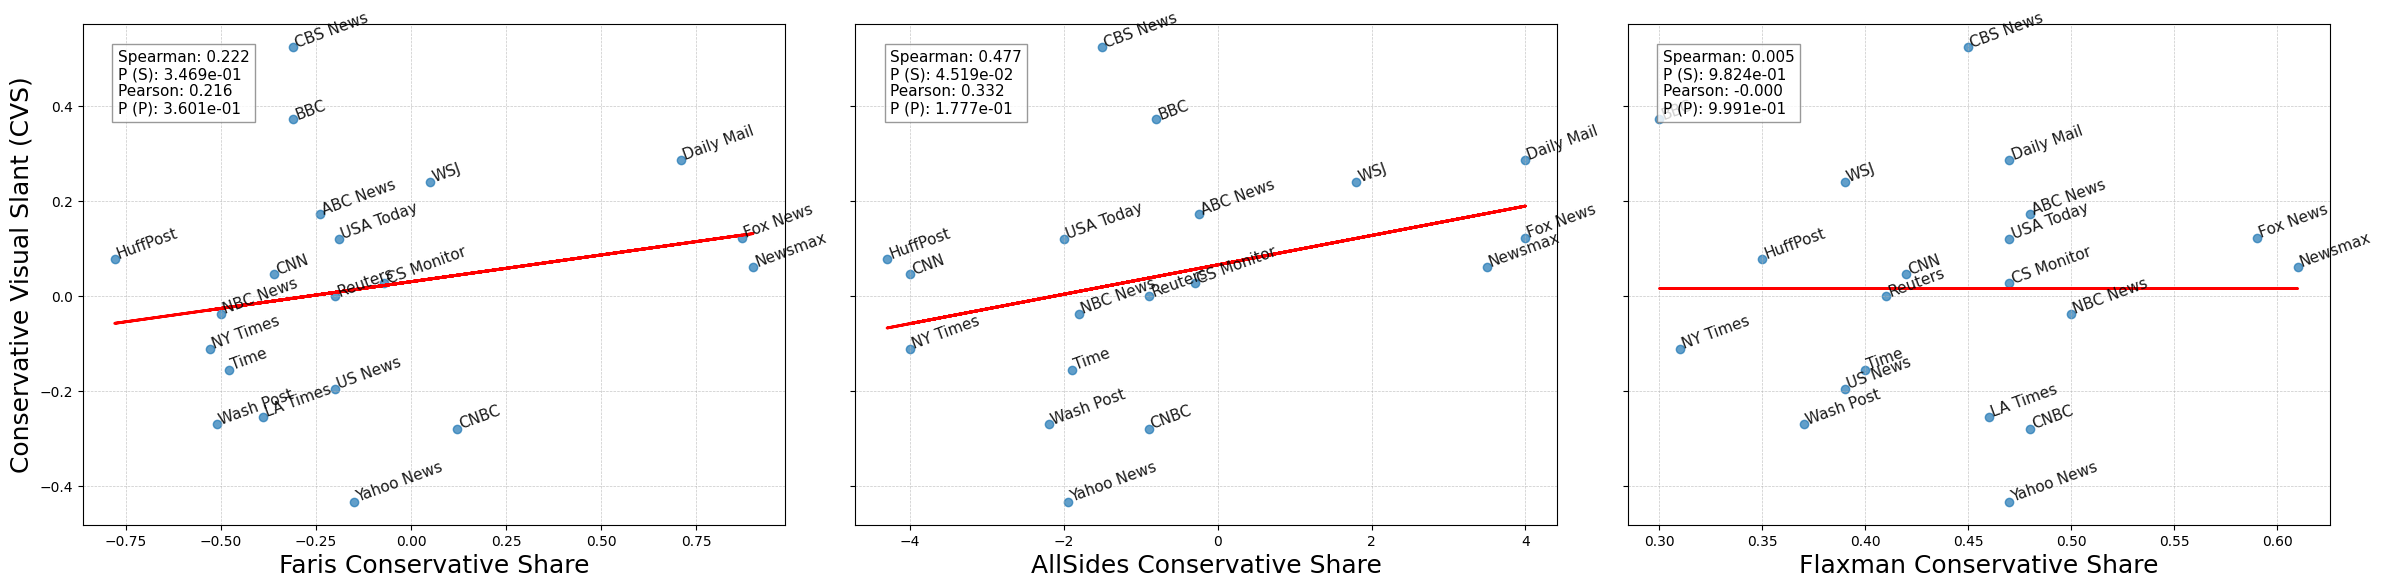

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
import statsmodels.api as sm
from scipy.stats import spearmanr, pearsonr

df = pd.read_csv('Final_CSV_For_Analysis_Brightness.csv').copy()


plt.style.use('default')

news_center_affiliations = {
    'www.bbc.com': 'Democratic', 'www.nytimes.com': 'Democratic', 'www.huffpost.com': 'Democratic',
    'www.washingtonpost.com': 'Democratic', 'www.wsj.com': 'Republican', 'www.cnn.com': 'Democratic',
    'www.cbsnews.com': 'Democratic', 'www.latimes.com': 'Neutral', 'www.dailymail.co.uk': 'Republican',
    'abcnews.go.com': 'Democratic', 'www.nbcnews.com': 'Democratic', 'www.foxnews.com': 'Republican',
    'www.newsmax.com': 'Republican', 'www.usnews.com': 'Neutral', 'time.com': 'Democratic',
    'www.reuters.com': 'Neutral', 'news.yahoo.com': 'Neutral', 'www.usatoday.com': 'Neutral',
    'www.cnbc.com': 'Democratic', 'www.csmonitor.com': 'Neutral'
}

short_names = {
    'www.bbc.com': 'BBC', 'www.nytimes.com': 'NY Times', 'www.huffpost.com': 'HuffPost',
    'www.washingtonpost.com': 'Wash Post', 'www.wsj.com': 'WSJ', 'www.cnn.com': 'CNN',
    'www.cbsnews.com': 'CBS News', 'www.latimes.com': 'LA Times', 'www.dailymail.co.uk': 'Daily Mail',
    'abcnews.go.com': 'ABC News', 'www.nbcnews.com': 'NBC News', 'www.foxnews.com': 'Fox News',
    'www.newsmax.com': 'Newsmax', 'www.usnews.com': 'US News', 'time.com': 'Time',
    'www.reuters.com': 'Reuters', 'news.yahoo.com': 'Yahoo News', 'www.usatoday.com': 'USA Today',
    'www.cnbc.com': 'CNBC', 'www.csmonitor.com': 'CS Monitor'
}

selected_news_centers = list(news_center_affiliations.keys())

mean_smile_effect = {
    'News Center': [],
    'Republican Politicians': [],
    'Democratic Politicians': []
}

for news_center in selected_news_centers:
    smile_column = f"Final_Ratio_{news_center}_epoch_20"
    if smile_column in df.columns:
        republican_mean_effect = df[(df['Real Person Side'] == 'Republican')][smile_column].mean()
        democratic_mean_effect = df[(df['Real Person Side'] == 'Democratic')][smile_column].mean()
        mean_smile_effect['News Center'].append(news_center)
        mean_smile_effect['Republican Politicians'].append(republican_mean_effect if not np.isnan(republican_mean_effect) else 0)
        mean_smile_effect['Democratic Politicians'].append(democratic_mean_effect if not np.isnan(democratic_mean_effect) else 0)

mean_smile_effect_df = pd.DataFrame(mean_smile_effect)
mean_smile_effect_df['Overall Polarization'] = (mean_smile_effect_df['Republican Politicians'] - mean_smile_effect_df['Democratic Politicians'])
mean_smile_effect_df = mean_smile_effect_df.sort_values(by='Overall Polarization', ascending=True)

fig3, ax3 = plt.subplots(figsize=(14, 8))
bar_colors = ['red' if value > 0 else 'blue' for value in mean_smile_effect_df['Overall Polarization']]
ax3.bar(mean_smile_effect_df['News Center'], mean_smile_effect_df['Overall Polarization'], color=bar_colors, alpha=0.8)
ax3.set_xlabel('News Outlet', fontsize=22)
ax3.set_ylabel('Conservative Visual Slant', fontsize=22)
ax3.set_xticks(range(len(mean_smile_effect_df['News Center'])))
ax3.set_xticklabels([short_names[nc] for nc in mean_smile_effect_df['News Center']], ha='right', rotation=40, fontsize=18)
ax3.tick_params(axis='y', labelsize=14)
ax3.grid(True, which='both', linestyle='--', linewidth=0.5)
fig3.tight_layout()
fig3.savefig('Fig_overall_polarization.png', dpi=70)
plt.show()

harvard = {'www.bbc.com': -0.31, 'www.nytimes.com': -0.53, 'www.huffpost.com': -0.78, 'www.washingtonpost.com': -0.51,
           'www.wsj.com': 0.05, 'www.usnews.com': -0.20, 'time.com': -0.48, 'www.reuters.com': -0.20, 'www.cnn.com': -0.36,
           'www.cbsnews.com': -0.31, 'www.latimes.com': -0.39, 'news.yahoo.com': -0.15, 'www.usatoday.com': -0.19,
           'www.dailymail.co.uk': 0.71, 'www.cnbc.com': 0.12, 'www.csmonitor.com': -0.07, 'abcnews.go.com': -0.24,
           'www.nbcnews.com': -0.50, 'www.foxnews.com': 0.87, 'www.newsmax.com': 0.9}

allsides = {'www.bbc.com': -0.8, 'www.nytimes.com': -4, 'www.huffpost.com': -4.3, 'www.washingtonpost.com': -2.2,
            'www.wsj.com': 1.8, 'time.com': -1.9, 'www.reuters.com': -0.89, 'www.cnn.com': -4, 'www.cbsnews.com': -1.5,
            'news.yahoo.com': -1.95, 'www.usatoday.com': -2, 'www.dailymail.co.uk': 4, 'www.cnbc.com': -0.9,
            'www.csmonitor.com': -0.3, 'abcnews.go.com': -0.24, 'www.nbcnews.com': -1.8, 'www.foxnews.com': 4,
            'www.newsmax.com': 3.5}

other_paper = {'www.bbc.com': 0.30, 'www.nytimes.com': 0.31, 'www.huffpost.com': 0.35, 'www.washingtonpost.com': 0.37,
               'www.wsj.com': 0.39, 'www.usnews.com': 0.39, 'time.com': 0.40, 'www.reuters.com': 0.41, 'www.cnn.com': 0.42,
               'www.cbsnews.com': 0.45, 'www.latimes.com': 0.46, 'news.yahoo.com': 0.47, 'www.usatoday.com': 0.47,
               'www.dailymail.co.uk': 0.47, 'www.cnbc.com': 0.48, 'www.csmonitor.com': 0.47, 'abcnews.go.com': 0.48,
               'www.nbcnews.com': 0.50, 'www.foxnews.com': 0.59, 'www.newsmax.com': 0.61}


def plot_three_regressions_side_by_side(
    conservative_shares,
    conservative_labels,
    filenames_label,
    output_filename
):
    fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharey=True)

    for ax, conservative_share, conservative_label in zip(
        axes, conservative_shares, conservative_labels
    ):
        valid_outlets = [
            nc for nc in mean_smile_effect_df['News Center']
            if nc in conservative_share
        ]

        x = [conservative_share[nc] for nc in valid_outlets]
        y = mean_smile_effect_df.loc[
            mean_smile_effect_df['News Center'].isin(valid_outlets),
            'Overall Polarization'
        ]

        spearman_corr, spearman_p_value = spearmanr(x, y)
        pearson_corr, pearson_p_value = pearsonr(x, y)

        x_with_constant = sm.add_constant(x)
        model = sm.OLS(y, x_with_constant).fit()
        intercept, slope = model.params.iloc[0], model.params.iloc[1]

        ax.scatter(x, y, alpha=0.7)
        ax.plot(
            x,
            intercept + slope * np.array(x),
            color='red',
            linestyle='-',
            linewidth=2
        )

        valid_short_names = [short_names[nc] for nc in valid_outlets]
        for i, short_name in enumerate(valid_short_names):
            ax.annotate(
                short_name,
                (x[i], y.iloc[i]),
                fontsize=11,
                alpha=0.9,
                rotation=20
            )

        stats_text = (
            f"Spearman: {spearman_corr:.3f}\n"
            f"P (S): {spearman_p_value:.3e}\n"
            f"Pearson: {pearson_corr:.3f}\n"
            f"P (P): {pearson_p_value:.3e}"
        )

        ax.text(
            0.05, 0.95,
            stats_text,
            transform=ax.transAxes,
            fontsize=11,
            verticalalignment='top',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
        )

        ax.set_xlabel(conservative_label, fontsize=18)
        ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

    axes[0].set_ylabel("Conservative Visual Slant (CVS)", fontsize=18)

    plt.tight_layout()
    plt.savefig(output_filename, dpi=100)
    plt.show()
    plt.close(fig)


plot_three_regressions_side_by_side(
    conservative_shares=[harvard, allsides, other_paper],
    conservative_labels=[
        "Faris Conservative Share",
        "AllSides Conservative Share",
        "Flaxman Conservative Share"
    ],
    filenames_label=[
        "Harvard",
        "AllSides",
        "OtherPaper"
    ],
    output_filename="Fig_ConservativeShare_vs_Polarization_Brightness.png"
)

### Visual Feature T: Sadness (Frown)

In [ ]:
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image, UnidentifiedImageError
import requests
from io import BytesIO
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from tqdm import tqdm
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import os
import matplotlib.pyplot as plt
import gensim
from gensim import corpora
from torchvision import models
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import numpy as np
from facenet_pytorch import InceptionResnetV1, MTCNN

torch.backends.cudnn.benchmark = True

class MultiHeadAttention(nn.Module):
    def __init__(self, embed_size, heads):
        super(MultiHeadAttention, self).__init__()
        self.embed_size = embed_size
        self.heads = heads
        self.head_dim = embed_size // heads
        assert self.head_dim * heads == embed_size
        self.values = nn.Linear(embed_size, embed_size, bias=False)
        self.keys = nn.Linear(embed_size, embed_size, bias=False)
        self.queries = nn.Linear(embed_size, embed_size, bias=False)
        self.fc_out = nn.Linear(embed_size, embed_size)

    def forward(self, values, keys, query):
        N = query.shape[0]
        value_len, key_len, query_len = values.shape[1], keys.shape[1], query.shape[1]
        values = self.values(values)
        keys = self.keys(keys)
        queries = self.queries(query)
        values = values.reshape(N, value_len, self.heads, self.head_dim)
        keys = keys.reshape(N, key_len, self.heads, self.head_dim)
        queries = queries.reshape(N, query_len, self.heads, self.head_dim)
        energy = torch.einsum("nqhd,nkhd->nhqk", [queries, keys])
        attention = torch.nn.functional.softmax(energy / (self.embed_size ** (1 / 2)), dim=3)
        out = torch.einsum("nhql,nlhd->nqhd", [attention, values]).reshape(
            N, query_len, self.heads * self.head_dim
        )
        out = self.fc_out(out)
        return out


class ImprovedMultiModalModel(nn.Module):
    def __init__(self, num_person_categories, num_party_categories, num_topics, num_classes,
                 num_date_categories, embedding_dim_person=8, embedding_dim_party=2,
                 embedding_dim_date=4, num_attention_heads=8, window_size=32):
        super(ImprovedMultiModalModel, self).__init__()
        self.face_vgg = InceptionResnetV1(pretrained='vggface2').eval()
        for param in list(self.face_vgg.parameters())[:-5]:
            param.requires_grad = False
        self.fc_vgg_1 = nn.Linear(512, 256)
        self.bn_vgg = nn.BatchNorm1d(256)
        self.dropout_vgg = nn.Dropout(0.3)
        self.person_embedding = nn.Embedding(num_person_categories, embedding_dim_person)
        self.party_embedding = nn.Embedding(num_party_categories, embedding_dim_party)
        self.date_embedding = nn.Embedding(num_date_categories, embedding_dim_date)
        self.fc_structured_proj = nn.Linear(embedding_dim_person + embedding_dim_party + num_topics + embedding_dim_date, 64)
        self.structured_attention = MultiHeadAttention(embed_size=64, heads=num_attention_heads)
        self.bn_structured = nn.BatchNorm1d(64)
        self.dropout_structured = nn.Dropout(0.4)
        self.fc_person_party_proj = nn.Linear(embedding_dim_person + embedding_dim_party, window_size)
        self.chunked_attention = MultiHeadAttention(embed_size=window_size, heads=num_attention_heads)
        resnet_pretrained = models.resnet101(pretrained=True)
        for param in list(resnet_pretrained.parameters())[:-10]:
            param.requires_grad = False
        self.features_resnet = nn.Sequential(*list(resnet_pretrained.children())[:-1])
        self.fc_resnet = nn.Linear(resnet_pretrained.fc.in_features, 512)
        self.bn_resnet = nn.BatchNorm1d(512)
        self.dropout_resnet = nn.Dropout(0.6)
        self.fc_out = nn.Linear(256 + 64 + 512, num_classes)
        self.dropout_out = nn.Dropout(0.5)

    def forward(self, resnet_img, face_img, person, party, topic_distribution, date):
        vgg_features = self.face_vgg(face_img)
        vgg_features = F.relu(self.bn_vgg(self.fc_vgg_1(vgg_features)))
        vgg_features = self.dropout_vgg(vgg_features)
        person_embedded = self.person_embedding(person)
        party_embedded = self.party_embedding(party)
        date_embedded = self.date_embedding(date)
        structured_data = torch.cat((person_embedded, party_embedded, topic_distribution, date_embedded), dim=1)
        structured_data_proj = F.relu(self.fc_structured_proj(structured_data))
        structured_data = self.structured_attention(structured_data_proj.unsqueeze(1), structured_data_proj.unsqueeze(1), structured_data_proj.unsqueeze(1)).squeeze(1)
        structured_data = F.relu(self.bn_structured(structured_data))
        structured_data = self.dropout_structured(structured_data)
        person_party_data = torch.cat((person_embedded, party_embedded), dim=1)
        person_party_proj = self.fc_person_party_proj(person_party_data).unsqueeze(1)
        vgg_chunks = vgg_features.view(vgg_features.size(0), 8, -1)
        attended_chunks = []
        for i in range(8):
            vgg_chunk = vgg_chunks[:, i, :].unsqueeze(1)
            attention_out = self.chunked_attention(person_party_proj, vgg_chunk, vgg_chunk).squeeze(1)
            attended_chunks.append(attention_out)
        attended_vgg_features = torch.cat(attended_chunks, dim=1)
        resnet_features = self.features_resnet(resnet_img)
        resnet_features = torch.flatten(resnet_features, 1)
        resnet_features = F.relu(self.bn_resnet(self.fc_resnet(resnet_features)))
        resnet_features = self.dropout_resnet(resnet_features)
        combined_features = torch.cat((attended_vgg_features, structured_data, resnet_features), dim=1)
        combined_features = self.dropout_out(combined_features)
        out = self.fc_out(combined_features)
        return out


df = pd.read_pickle('cleaned_complete_data_Face_Verification_Info_Raady_MLModel_Date.pkl')
df = df[df['dataset_type'] == 'val'].reset_index(drop=True)

unique_persons = df['Top1_Person'].nunique()
num_person_categories = unique_persons
num_party_categories = 2
num_topics = 40
num_date_features = len([col for col in df.columns if col.startswith('Date_')])
num_classes = len(df['News Center'].unique())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_attention_layers = 1

person_encoder = LabelEncoder()
party_encoder = LabelEncoder()
date_encoder = LabelEncoder()
outlet_encoder = LabelEncoder()

df['YearMonth'] = pd.to_datetime(df['Date_Pub'], errors='coerce').dt.to_period('M').astype(str)

person_encoder.fit(df['Top1_Person'])
party_encoder.fit(df['Real Person Side'])
date_encoder.fit(df['YearMonth'])
outlet_encoder.fit(df['News Center'])

df['person_encoded'] = person_encoder.transform(df['Top1_Person'])
df['party_encoded'] = party_encoder.transform(df['Real Person Side'])
df['date_encoded'] = date_encoder.transform(df['YearMonth'])
df['outlet_encoded'] = outlet_encoder.transform(df['News Center'])

num_person_categories = len(person_encoder.classes_)
num_party_categories = len(party_encoder.classes_)
num_date_categories = len(date_encoder.classes_)
num_classes = len(outlet_encoder.classes_)
num_topics = 40
embedding_dim_person = 8
embedding_dim_party = 2
embedding_dim_date = 4
model = ImprovedMultiModalModel(
    num_person_categories=num_person_categories,
    num_party_categories=num_party_categories,
    num_topics=num_topics,
    num_classes=num_classes,
    num_date_categories=num_date_categories,
    embedding_dim_person=embedding_dim_person,
    embedding_dim_party=embedding_dim_party,
    embedding_dim_date=embedding_dim_date,
    num_attention_heads=8
)


class AdaptedStaticImageDataset(Dataset):
    def __init__(self, dataframe, image_dir='data/Counterfactuals', transform=None, face_transform=None, smile=False, num_images=3):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.transform = transform
        self.face_transform = face_transform
        self.smile = smile
        self.num_images = num_images
        self.mtcnn = MTCNN(keep_all=False, device=torch.device('cpu'), thresholds=[0.4, 0.5, 0.6], min_face_size=15, factor=0.6)
        self.person_encoder = LabelEncoder()
        self.outlet_encoder = LabelEncoder()
        self.party_encoder = LabelEncoder()
        self.date_encoder = LabelEncoder()
        self.person_encoder.fit(dataframe['Top1_Person'])
        self.outlet_encoder.fit(dataframe['News Center'])
        self.party_encoder.fit(dataframe['Real Person Side'])
        self.date_encoder.fit(dataframe['YearMonth'])
        self.person_encoded = self.person_encoder.transform(dataframe['Top1_Person'])
        self.outlet_encoded = self.outlet_encoder.transform(dataframe['News Center'])
        self.party_encoded = self.party_encoder.transform(dataframe['Real Person Side'])
        self.dates = self.date_encoder.transform(dataframe['YearMonth'])
        self.topic_columns = [col for col in dataframe.columns if col.startswith('topic_')]

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        politician = self.dataframe.iloc[idx]['Top1_Person'].replace(' ', '_')
        img_suffix = '_with_sad' if self.smile else ''
        images = []
        face_images = []
        for i in range(1, self.num_images + 1):
            img_path = os.path.join(self.image_dir, f"{politician}{img_suffix}_{i}.jpg")
            try:
                img = Image.open(img_path).convert('RGB')
                face_img = self.mtcnn(img)
                if face_img is None:
                    face_img = transforms.Resize((224, 224))(img)
                    face_img = transforms.ToPILImage()(face_img)
                else:
                    face_img = transforms.Resize((224, 224))(face_img)
                    face_img = transforms.ToPILImage()(face_img)
                if self.transform:
                    img = self.transform(img)
                if self.face_transform:
                    face_img = self.face_transform(face_img)
                images.append(img)
                face_images.append(face_img)
            except (FileNotFoundError, UnidentifiedImageError):
                return self.__getitem__((idx + 1) % len(self.dataframe))
        label = self.outlet_encoded[idx]
        person = self.person_encoded[idx]
        party = self.party_encoded[idx]
        date = torch.tensor(self.dates[idx], dtype=torch.long)
        topic_distribution = self.dataframe.iloc[idx][self.topic_columns].values
        topic_distribution = np.array(topic_distribution, dtype=np.float32)
        topic_distribution = torch.tensor(topic_distribution)
        return images, face_images, torch.tensor(label, dtype=torch.long), torch.tensor(person, dtype=torch.long), torch.tensor(party, dtype=torch.long), topic_distribution, date



transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.985, 0.256, 0.406], std=[0.629, 0.124, 0.125]),
])


face_transform = transforms.Compose([
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_images = 3

batch_size = 32
num_workers = 30 

adapted_dataset_without_smile = AdaptedStaticImageDataset(df, transform=transform, face_transform=face_transform, smile=False, num_images=3)
adapted_loader_without_smile = DataLoader(adapted_dataset_without_smile, batch_size=batch_size, shuffle=False, num_workers=num_workers)
adapted_dataset_with_smile = AdaptedStaticImageDataset(df, transform=transform, face_transform=face_transform, smile=True, num_images=3)
adapted_loader_with_smile = DataLoader(adapted_dataset_with_smile, batch_size=batch_size, shuffle=False, num_workers=num_workers)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


def calculate_probabilities(static_loader, is_smile, model, device):
    prediction_probs = []
    model.eval()
    
    use_amp = torch.cuda.is_available()
    
    with torch.no_grad():
        for batch in tqdm(static_loader, desc=f'Predicting {"with" if is_smile else "without"} smile'):
            images_list, face_images_list, label, person, party, topic_distribution, date = batch
            
            person = person.to(device)
            party = party.to(device)
            topic_distribution = topic_distribution.to(device)
            date = date.to(device)
            
            batch_results_per_view = []
            
            for i in range(len(images_list)): 
                img = images_list[i].to(device)
                face_img = face_images_list[i].to(device)
                
                with torch.cuda.amp.autocast(enabled=use_amp):
                    output = model(img, face_img, person, party, topic_distribution, date)
                    probs = torch.softmax(output, dim=1)
                
                batch_results_per_view.append(probs.cpu().numpy())
            
            batch_probs_stacked = np.stack(batch_results_per_view, axis=1)
            
            for sample_probs in batch_probs_stacked:
                prediction_probs.append(sample_probs)
                
    return prediction_probs


for epoch in range(20, 21):
    print(f"Processing epoch {epoch}")
    checkpoint_path = f'model_checkpoint_MultiClasses_With_Date_6/epoch_{epoch}.pth'
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    model.to(device)
    
    prediction_probs_without_smile = calculate_probabilities(adapted_loader_without_smile, is_smile=False, model=model, device=device)
    prediction_probs_with_smile = calculate_probabilities(adapted_loader_with_smile, is_smile=True, model=model, device=device)
    
    class_names = adapted_dataset_without_smile.outlet_encoder.classes_
    prob_columns_without_smile = []
    prob_columns_with_smile = []
    
    for i in range(3):
        prob_without_smile = [np.squeeze(pred[i]) if pred is not None and len(pred) > i else None for pred in prediction_probs_without_smile]
        prob_with_smile = [np.squeeze(pred[i]) if pred is not None and len(pred) > i else None for pred in prediction_probs_with_smile]
        
        temp_df_without_smile = pd.DataFrame(prob_without_smile, columns=[f'prob_img{i+1}_{class_name}_without_smile' for class_name in class_names])
        temp_df_with_smile = pd.DataFrame(prob_with_smile, columns=[f'prob_img{i+1}_{class_name}_with_smile' for class_name in class_names])
        prob_columns_without_smile.append(temp_df_without_smile)
        prob_columns_with_smile.append(temp_df_with_smile)
    
    df_combined = pd.concat([df] + prob_columns_without_smile + prob_columns_with_smile, axis=1)
    reuters = 'www.reuters.com'
    final_ratios = {}
    final_diffs = {}
    
    for news_center in class_names:
        individual_ratios_list = []
        individual_diffs_list = []
        for i in range(1, 4):
            prob_news_center_with_smile_col = f'prob_img{i}_{news_center}_with_smile'
            prob_reuters_with_smile_col = f'prob_img{i}_{reuters}_with_smile'
            prob_news_center_without_smile_col = f'prob_img{i}_{news_center}_without_smile'
            prob_reuters_without_smile_col = f'prob_img{i}_{reuters}_without_smile'
            
            prob_news_center_with_smile = df_combined[prob_news_center_with_smile_col].values
            prob_reuters_with_smile = df_combined[prob_reuters_with_smile_col].values
            prob_news_center_without_smile = df_combined[prob_news_center_without_smile_col].values
            prob_reuters_without_smile = df_combined[prob_reuters_without_smile_col].values
            
            with np.errstate(divide='ignore', invalid='ignore'):
                factual_ratio = np.where(prob_reuters_without_smile > 0, prob_news_center_without_smile / prob_reuters_without_smile, 0)
                counterfactual_ratio = np.where(prob_reuters_with_smile > 0, prob_news_center_with_smile / prob_reuters_with_smile, 0)
                individual_ratios = np.where((factual_ratio > 0) & (counterfactual_ratio > 0),
                                             np.log(counterfactual_ratio / factual_ratio), 0)
                individual_diff = np.where((prob_news_center_with_smile != None) & (prob_news_center_without_smile != None),
                                           prob_news_center_with_smile - prob_news_center_without_smile, 0)
            
            df_combined[f'Ratio_{i}_{news_center}'] = individual_ratios
            df_combined[f'Diff_{i}_{news_center}'] = individual_diff
            individual_ratios_list.append(individual_ratios)
            individual_diffs_list.append(individual_diff)
        
        mean_final_ratio = np.mean(individual_ratios_list, axis=0)
        mean_final_diff = np.mean(individual_diffs_list, axis=0)
        df_combined[f'Final_Ratio_{news_center}_epoch_{epoch}'] = mean_final_ratio
        df_combined[f'Final_Diff_{news_center}_epoch_{epoch}'] = mean_final_diff
    
    output_file = f'Final_CSV_For_Analysis_Sadness.csv'
    df_combined.to_csv(output_file, index=False)
    print(f"Final_Ratio and Final_Diff for epoch {epoch} have been calculated and saved to {output_file}.")

### Counterfactual Validation Using Sadness (Figure A.17)

Using counterfactual estimates generated by the **PMCIG algorithm** with respect to the visual feature \(T\) (image frown), we evaluate how brightness-based visual slant aligns with existing **non-visual benchmarks of news media slant**. This analysis examines whether outlets exhibit systematic and consistent ideological positioning through brightness manipulation, and whether such patterns translate into visual slant and polarization comparable to those observed for facial expressions.

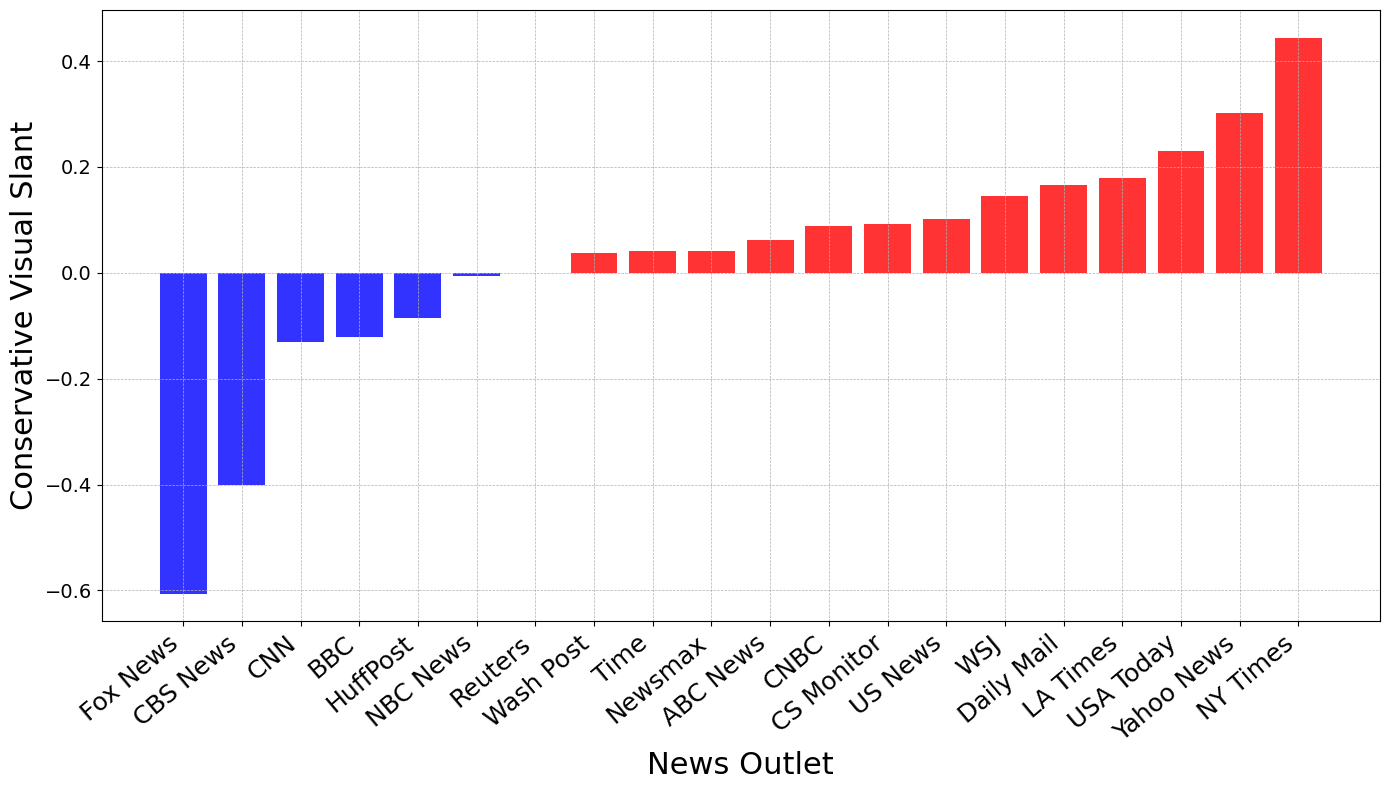

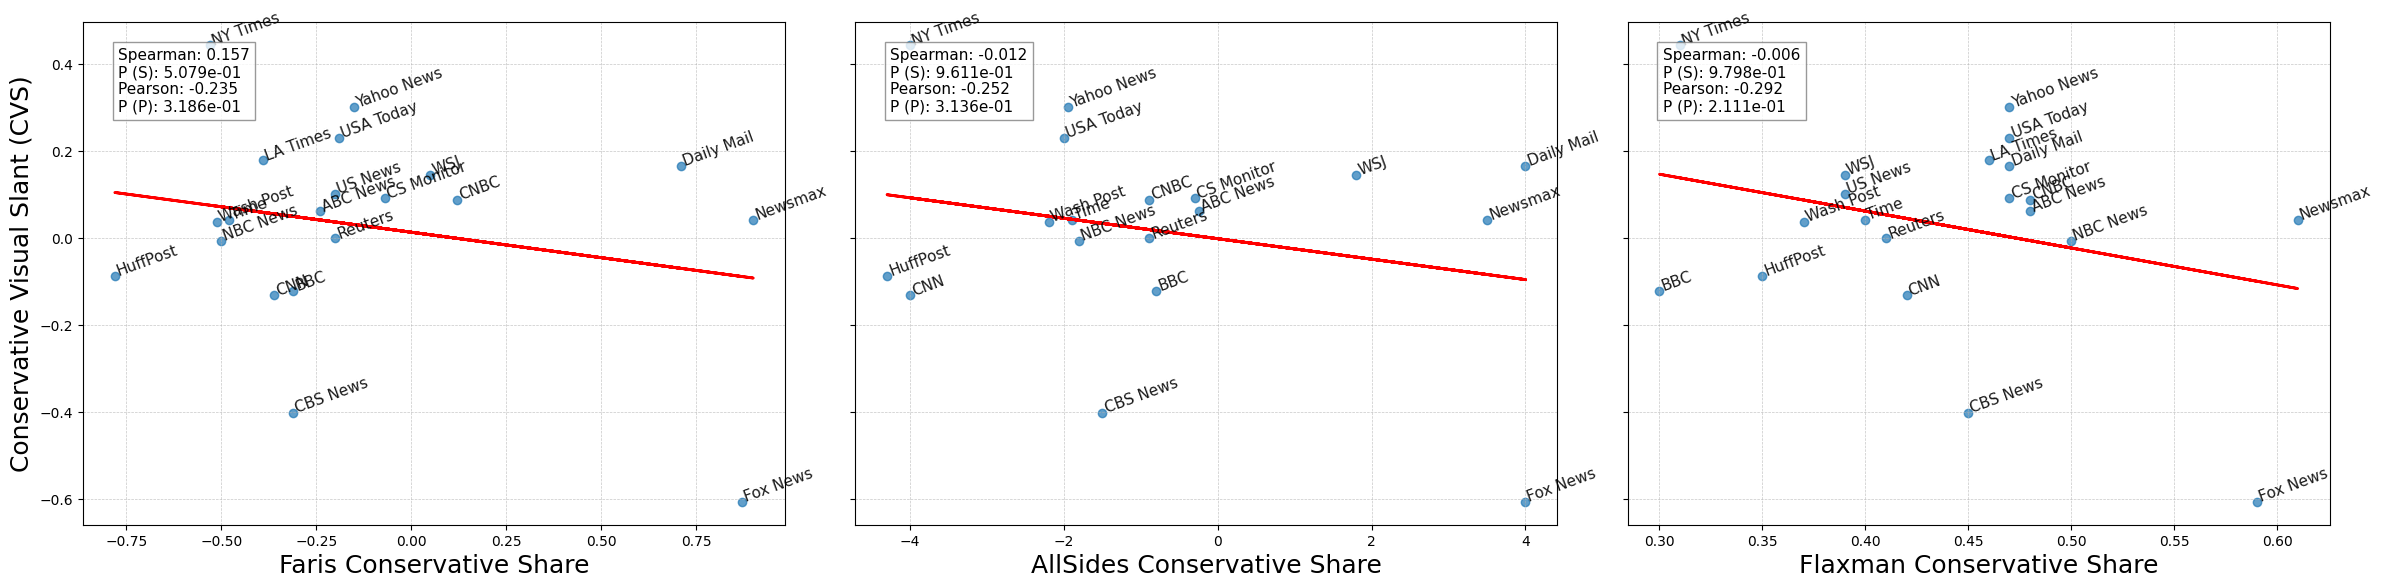

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
import statsmodels.api as sm
from scipy.stats import spearmanr, pearsonr

df = pd.read_csv('Final_CSV_For_Analysis_Sadness.csv').copy()

plt.style.use('default')

news_center_affiliations = {
    'www.bbc.com': 'Democratic', 'www.nytimes.com': 'Democratic', 'www.huffpost.com': 'Democratic',
    'www.washingtonpost.com': 'Democratic', 'www.wsj.com': 'Republican', 'www.cnn.com': 'Democratic',
    'www.cbsnews.com': 'Democratic', 'www.latimes.com': 'Neutral', 'www.dailymail.co.uk': 'Republican',
    'abcnews.go.com': 'Democratic', 'www.nbcnews.com': 'Democratic', 'www.foxnews.com': 'Republican',
    'www.newsmax.com': 'Republican', 'www.usnews.com': 'Neutral', 'time.com': 'Democratic',
    'www.reuters.com': 'Neutral', 'news.yahoo.com': 'Neutral', 'www.usatoday.com': 'Neutral',
    'www.cnbc.com': 'Democratic', 'www.csmonitor.com': 'Neutral'
}

short_names = {
    'www.bbc.com': 'BBC', 'www.nytimes.com': 'NY Times', 'www.huffpost.com': 'HuffPost',
    'www.washingtonpost.com': 'Wash Post', 'www.wsj.com': 'WSJ', 'www.cnn.com': 'CNN',
    'www.cbsnews.com': 'CBS News', 'www.latimes.com': 'LA Times', 'www.dailymail.co.uk': 'Daily Mail',
    'abcnews.go.com': 'ABC News', 'www.nbcnews.com': 'NBC News', 'www.foxnews.com': 'Fox News',
    'www.newsmax.com': 'Newsmax', 'www.usnews.com': 'US News', 'time.com': 'Time',
    'www.reuters.com': 'Reuters', 'news.yahoo.com': 'Yahoo News', 'www.usatoday.com': 'USA Today',
    'www.cnbc.com': 'CNBC', 'www.csmonitor.com': 'CS Monitor'
}

selected_news_centers = list(news_center_affiliations.keys())

mean_smile_effect = {
    'News Center': [],
    'Republican Politicians': [],
    'Democratic Politicians': []
}

for news_center in selected_news_centers:
    smile_column = f"Final_Ratio_{news_center}_epoch_20"
    if smile_column in df.columns:
        republican_mean_effect = df[(df['Real Person Side'] == 'Republican')][smile_column].mean()
        democratic_mean_effect = df[(df['Real Person Side'] == 'Democratic')][smile_column].mean()
        mean_smile_effect['News Center'].append(news_center)
        mean_smile_effect['Republican Politicians'].append(republican_mean_effect if not np.isnan(republican_mean_effect) else 0)
        mean_smile_effect['Democratic Politicians'].append(democratic_mean_effect if not np.isnan(democratic_mean_effect) else 0)

mean_smile_effect_df = pd.DataFrame(mean_smile_effect)
mean_smile_effect_df['Overall Polarization'] = (mean_smile_effect_df['Republican Politicians'] - mean_smile_effect_df['Democratic Politicians'])
mean_smile_effect_df = mean_smile_effect_df.sort_values(by='Overall Polarization', ascending=True)

fig3, ax3 = plt.subplots(figsize=(14, 8))
bar_colors = ['red' if value > 0 else 'blue' for value in mean_smile_effect_df['Overall Polarization']]
ax3.bar(mean_smile_effect_df['News Center'], mean_smile_effect_df['Overall Polarization'], color=bar_colors, alpha=0.8)
ax3.set_xlabel('News Outlet', fontsize=22)
ax3.set_ylabel('Conservative Visual Slant', fontsize=22)
ax3.set_xticks(range(len(mean_smile_effect_df['News Center'])))
ax3.set_xticklabels([short_names[nc] for nc in mean_smile_effect_df['News Center']], ha='right', rotation=40, fontsize=18)
ax3.tick_params(axis='y', labelsize=14)
ax3.grid(True, which='both', linestyle='--', linewidth=0.5)
fig3.tight_layout()
fig3.savefig('Fig_overall_polarization.png', dpi=70)
plt.show()

harvard = {'www.bbc.com': -0.31, 'www.nytimes.com': -0.53, 'www.huffpost.com': -0.78, 'www.washingtonpost.com': -0.51,
           'www.wsj.com': 0.05, 'www.usnews.com': -0.20, 'time.com': -0.48, 'www.reuters.com': -0.20, 'www.cnn.com': -0.36,
           'www.cbsnews.com': -0.31, 'www.latimes.com': -0.39, 'news.yahoo.com': -0.15, 'www.usatoday.com': -0.19,
           'www.dailymail.co.uk': 0.71, 'www.cnbc.com': 0.12, 'www.csmonitor.com': -0.07, 'abcnews.go.com': -0.24,
           'www.nbcnews.com': -0.50, 'www.foxnews.com': 0.87, 'www.newsmax.com': 0.9}

allsides = {'www.bbc.com': -0.8, 'www.nytimes.com': -4, 'www.huffpost.com': -4.3, 'www.washingtonpost.com': -2.2,
            'www.wsj.com': 1.8, 'time.com': -1.9, 'www.reuters.com': -0.89, 'www.cnn.com': -4, 'www.cbsnews.com': -1.5,
            'news.yahoo.com': -1.95, 'www.usatoday.com': -2, 'www.dailymail.co.uk': 4, 'www.cnbc.com': -0.9,
            'www.csmonitor.com': -0.3, 'abcnews.go.com': -0.24, 'www.nbcnews.com': -1.8, 'www.foxnews.com': 4,
            'www.newsmax.com': 3.5}

other_paper = {'www.bbc.com': 0.30, 'www.nytimes.com': 0.31, 'www.huffpost.com': 0.35, 'www.washingtonpost.com': 0.37,
               'www.wsj.com': 0.39, 'www.usnews.com': 0.39, 'time.com': 0.40, 'www.reuters.com': 0.41, 'www.cnn.com': 0.42,
               'www.cbsnews.com': 0.45, 'www.latimes.com': 0.46, 'news.yahoo.com': 0.47, 'www.usatoday.com': 0.47,
               'www.dailymail.co.uk': 0.47, 'www.cnbc.com': 0.48, 'www.csmonitor.com': 0.47, 'abcnews.go.com': 0.48,
               'www.nbcnews.com': 0.50, 'www.foxnews.com': 0.59, 'www.newsmax.com': 0.61}


def plot_three_regressions_side_by_side(
    conservative_shares,
    conservative_labels,
    filenames_label,
    output_filename
):
    fig, axes = plt.subplots(1, 3, figsize=(24, 6), sharey=True)

    for ax, conservative_share, conservative_label in zip(
        axes, conservative_shares, conservative_labels
    ):
        valid_outlets = [
            nc for nc in mean_smile_effect_df['News Center']
            if nc in conservative_share
        ]

        x = [conservative_share[nc] for nc in valid_outlets]
        y = mean_smile_effect_df.loc[
            mean_smile_effect_df['News Center'].isin(valid_outlets),
            'Overall Polarization'
        ]

        spearman_corr, spearman_p_value = spearmanr(x, y)
        pearson_corr, pearson_p_value = pearsonr(x, y)

        x_with_constant = sm.add_constant(x)
        model = sm.OLS(y, x_with_constant).fit()
        intercept, slope = model.params.iloc[0], model.params.iloc[1]

        ax.scatter(x, y, alpha=0.7)
        ax.plot(
            x,
            intercept + slope * np.array(x),
            color='red',
            linestyle='-',
            linewidth=2
        )

        valid_short_names = [short_names[nc] for nc in valid_outlets]
        for i, short_name in enumerate(valid_short_names):
            ax.annotate(
                short_name,
                (x[i], y.iloc[i]),
                fontsize=11,
                alpha=0.9,
                rotation=20
            )

        stats_text = (
            f"Spearman: {spearman_corr:.3f}\n"
            f"P (S): {spearman_p_value:.3e}\n"
            f"Pearson: {pearson_corr:.3f}\n"
            f"P (P): {pearson_p_value:.3e}"
        )

        ax.text(
            0.05, 0.95,
            stats_text,
            transform=ax.transAxes,
            fontsize=11,
            verticalalignment='top',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
        )

        ax.set_xlabel(conservative_label, fontsize=18)
        ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

    axes[0].set_ylabel("Conservative Visual Slant (CVS)", fontsize=18)

    plt.tight_layout()
    plt.savefig(output_filename, dpi=100)
    plt.show()
    plt.close(fig)


plot_three_regressions_side_by_side(
    conservative_shares=[harvard, allsides, other_paper],
    conservative_labels=[
        "Faris Conservative Share",
        "AllSides Conservative Share",
        "Flaxman Conservative Share"
    ],
    filenames_label=[
        "Harvard",
        "AllSides",
        "OtherPaper"
    ],
    output_filename="Fig_ConservativeShare_vs_Polarization_Sadness.png"
)

## Reduced-Form Analysis of Visual Polarization

We begin our reduced-form analysis by **extracting low-dimensional visual features** from news images using **DeepFace**, focusing on facial emotion signals that proxy for visual favorability. These features provide a tractable summary of visual content that allows us to study polarization using standard econometric tools.

Following the framework of **Boxell et al.**, we first estimate a baseline specification that relates visual favorability to politician party affiliation **without fixed effects**, capturing raw partisan differences in visual portrayal across outlets. We then introduce **outlet fixed effects and outlet–party interactions**, which isolate outlet-specific partisan visual slant while controlling for systematic differences across politicians and news organizations.

Using this fixed-effects specification, we recover an outlet-level measure of conservative versus liberal **nonverbal visual slant**. We assess the validity of this reduced-form measure by comparing it to established **non-visual benchmarks of media ideology** (e.g., Harvard/Faris, AllSides, and Flaxman). This exercise highlights the limits of reduced-form approaches in high-dimensional visual settings and motivates our counterfactual PMCIG framework for measuring visual polarization.

### Extraction of Facial Emotion Features

We extract **facial emotion features** from news images using **DeepFace** with an MTCNN face detector. For each image, we obtain continuous scores for standard emotion categories (e.g., happy, sad, angry, fear) along with indicators for face detection and confidence. These low-dimensional, interpretable visual features serve as inputs to the reduced-form analysis of visual slant and polarization.

In [ ]:
import pandas as pd
import os
from deepface import DeepFace
from tqdm import tqdm

DATA_PATH = 'data/Final_CSV_For_Analysis.pkl'
IMAGE_DIR = 'data/images_Polarization'
OUTPUT_PATH = 'data/Final_CSV_For_Analysis_with_Emotions.csv'
BATCH_SAVE_EVERY = 500

df = pd.read_pickle(DATA_PATH)
df["YearMonth"] = pd.to_datetime(df["Date_Pub"], errors="coerce").dt.to_period("M").astype(str)

EMOTIONS = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']
EXTRA_COLS = ['dominant_emotion', 'face_confidence', 'face_detected']

for col in EMOTIONS + EXTRA_COLS:
    df[col] = None

for idx in tqdm(range(len(df)), desc="Extracting emotions"):
    img_id = df.iloc[idx]['ID']
    img_path = os.path.join(IMAGE_DIR, f"{img_id}.jpg")

    if not os.path.exists(img_path):
        df.at[df.index[idx], 'face_detected'] = False
        continue

    try:
        results = DeepFace.analyze(
            img_path=img_path,
            actions=['emotion'],
            enforce_detection=False,
            detector_backend='mtcnn',
            silent=True
        )

        if isinstance(results, list):
            result = results[0]
        else:
            result = results

        emotion_scores = result.get('emotion', {})
        for emo in EMOTIONS:
            df.at[df.index[idx], emo] = emotion_scores.get(emo, 0.0)

        df.at[df.index[idx], 'dominant_emotion'] = result.get('dominant_emotion', None)
        df.at[df.index[idx], 'face_confidence'] = result.get('face_confidence', None)
        df.at[df.index[idx], 'face_detected'] = True

    except Exception as e:
        df.at[df.index[idx], 'face_detected'] = False
        print(f"Error on ID={img_id}: {e}")

    if (idx + 1) % BATCH_SAVE_EVERY == 0:
        df.to_csv(OUTPUT_PATH, index=False)

for emo in EMOTIONS:
    df[emo] = pd.to_numeric(df[emo], errors='coerce')

df.to_csv(OUTPUT_PATH, index=False)
df.to_pickle(OUTPUT_PATH.replace('.csv', '.pkl'))

detected = df['face_detected'] == True
print(f"\nFaces detected: {detected.sum()} / {len(df)} ({detected.mean()*100:.1f}%)")
print(df.loc[detected, EMOTIONS].mean().sort_values(ascending=False).to_string())
print(df.loc[detected, 'dominant_emotion'].value_counts().to_string())

### Reduced-Form Analysis without Fixed Effects (Figure A.4)

We begin with a **baseline reduced-form specification without fixed effects**, relating facial-emotion–based visual favorability to politician party affiliation. This specification captures raw partisan differences in visual portrayal across outlets and provides a benchmark against which we later assess the role of outlet fixed effects. We validate the resulting outlet-level nonverbal slant by comparing it to established **non-visual news media ideology benchmarks**.

/home/jupyter-hoc_project/.local/lib/python3.9/site-packages/statsmodels/base/model.py:1888: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 20, but rank is 1
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:                    fav   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     222.6
Date:                Tue, 03 Feb 2026   Prob (F-statistic):           6.06e-12
Time:                        13:07:17   Log-Likelihood:            -3.5289e+05
No. Observations:               63015   AIC:                         7.058e+05
Df Residuals:                   62994   BIC:                         7.060e+05
Df Model:                          20                                         
Covariance Type:              cluster                                         
                                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

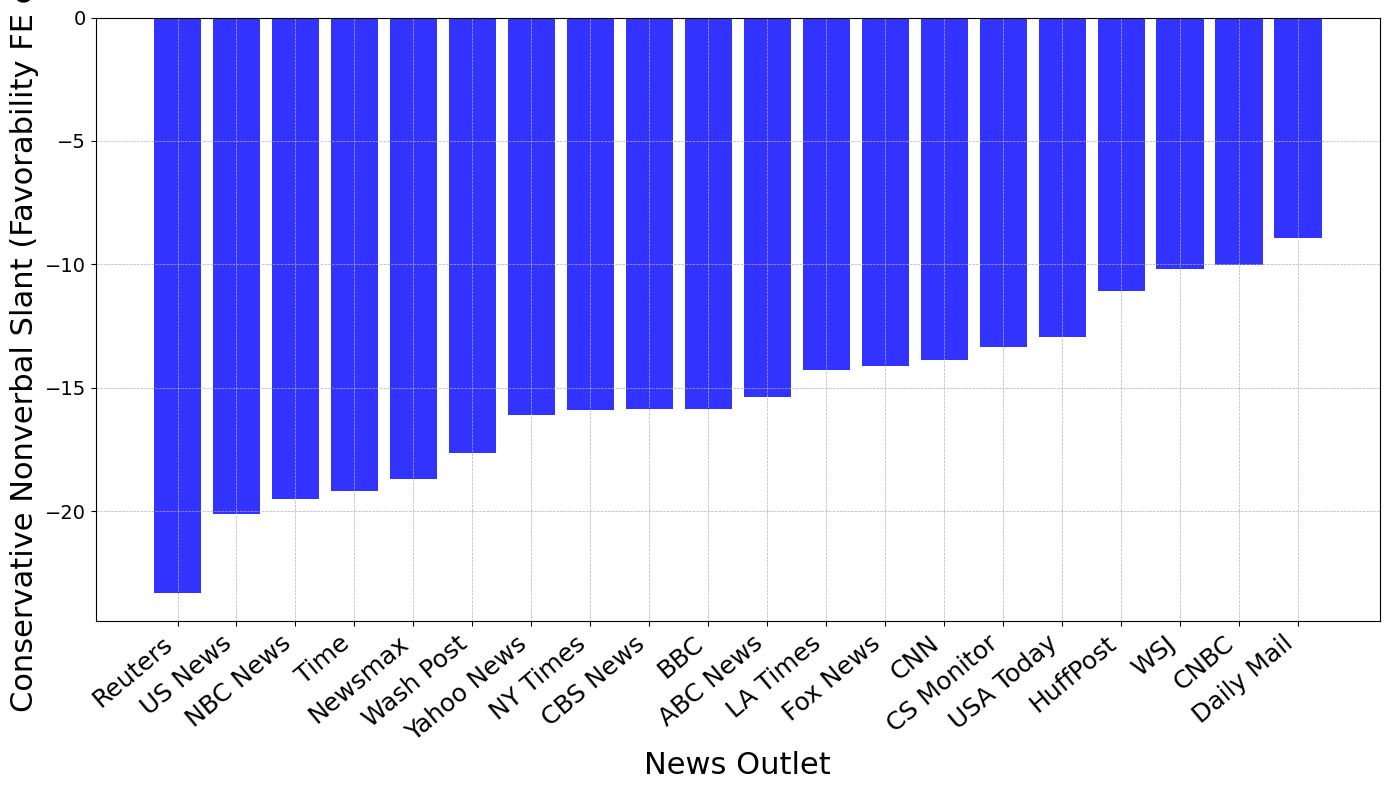

Running 500 permutations for Fig_Harvard_Correlation_vs_FavSlant.png...


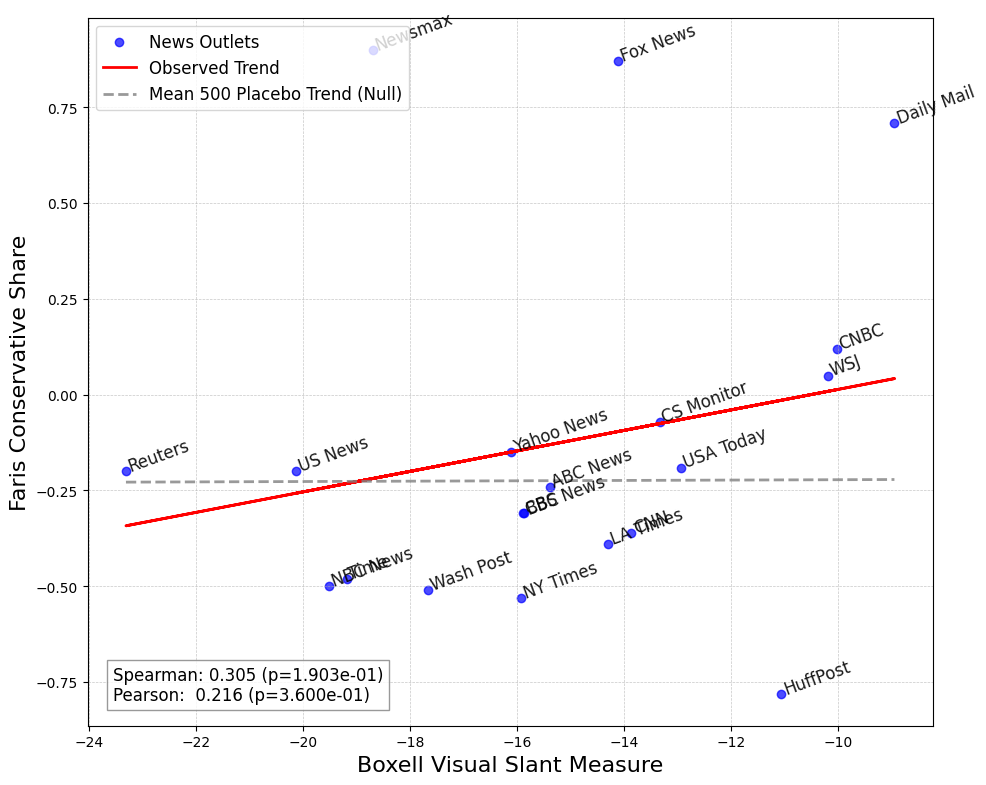

Running 500 permutations for Fig_Allsides_Correlation_vs_FavSlant.png...


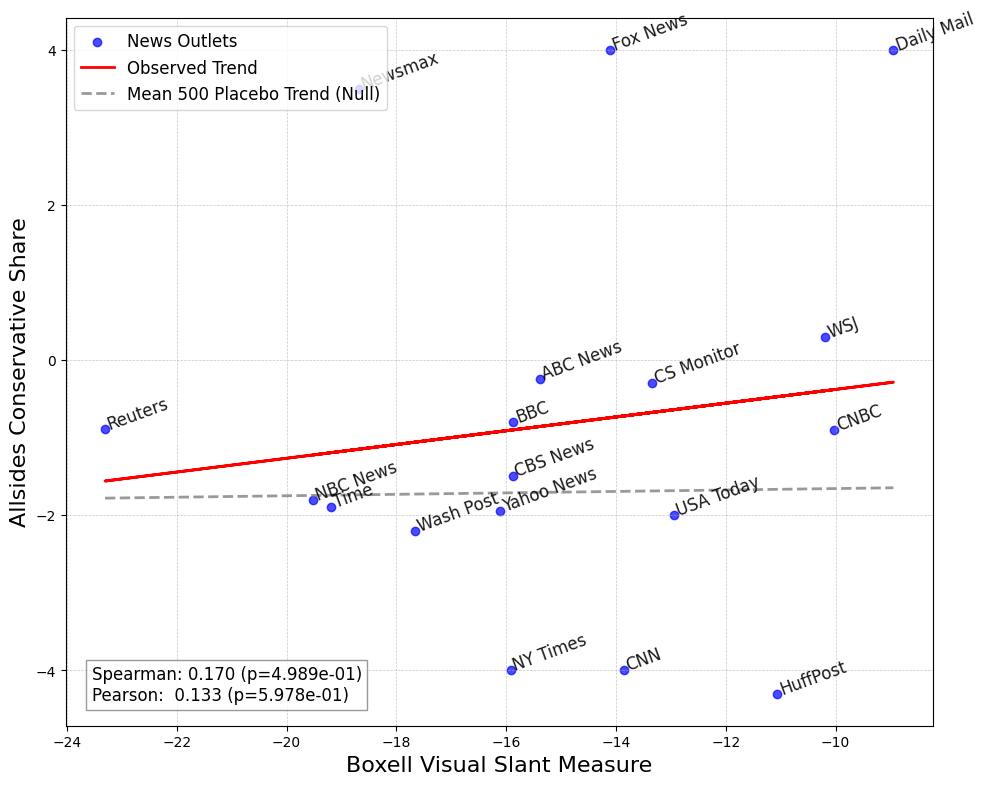

Running 500 permutations for Fig_Flaxman_Correlation_vs_FavSlant.png...


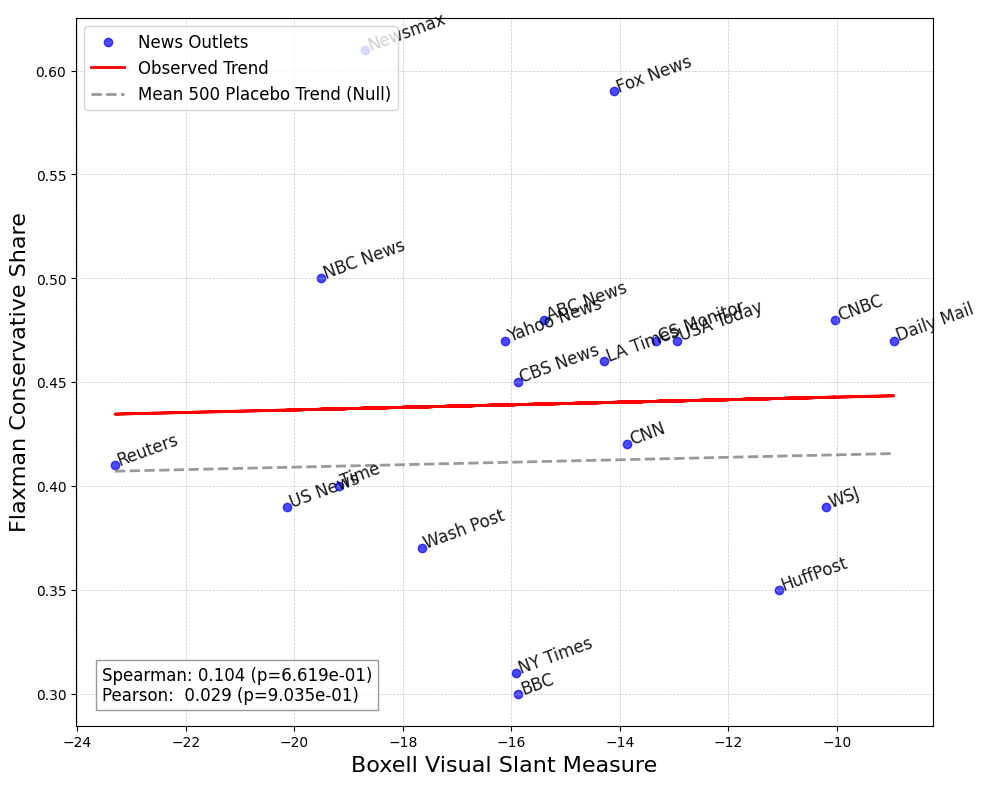

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import spearmanr, pearsonr
plt.style.use("default")

np.random.seed(42)
N_PERMUTATIONS = 1000

CSV_PATH = "data/Final_CSV_For_Analysis_with_Emotions.csv"

df = pd.read_csv(CSV_PATH).copy()
df = df[df["Real Person Side"].isin(["Republican", "Democratic"])].copy()

POLITICIAN_COL = "Top1_Person"
OUTLET_COL = "News Center"

news_center_affiliations = {
    'www.bbc.com': 'Democratic', 'www.nytimes.com': 'Democratic', 'www.huffpost.com': 'Democratic',
    'www.washingtonpost.com': 'Democratic', 'www.wsj.com': 'Republican', 'www.cnn.com': 'Democratic',
    'www.cbsnews.com': 'Democratic', 'www.latimes.com': 'Neutral', 'www.dailymail.co.uk': 'Republican',
    'abcnews.go.com': 'Democratic', 'www.nbcnews.com': 'Democratic', 'www.foxnews.com': 'Republican',
    'www.newsmax.com': 'Republican', 'www.usnews.com': 'Neutral', 'time.com': 'Democratic',
    'www.reuters.com': 'Neutral', 'news.yahoo.com': 'Neutral', 'www.usatoday.com': 'Neutral',
    'www.cnbc.com': 'Democratic', 'www.csmonitor.com': 'Neutral'
}

short_names = {
    'www.bbc.com': 'BBC', 'www.nytimes.com': 'NY Times', 'www.huffpost.com': 'HuffPost',
    'www.washingtonpost.com': 'Wash Post', 'www.wsj.com': 'WSJ', 'www.cnn.com': 'CNN',
    'www.cbsnews.com': 'CBS News', 'www.latimes.com': 'LA Times', 'www.dailymail.co.uk': 'Daily Mail',
    'abcnews.go.com': 'ABC News', 'www.nbcnews.com': 'NBC News', 'www.foxnews.com': 'Fox News',
    'www.newsmax.com': 'Newsmax', 'www.usnews.com': 'US News', 'time.com': 'Time',
    'www.reuters.com': 'Reuters', 'news.yahoo.com': 'Yahoo News', 'www.usatoday.com': 'USA Today',
    'www.cnbc.com': 'CNBC', 'www.csmonitor.com': 'CS Monitor'
}

harvard = {
    'www.bbc.com': -0.31, 'www.nytimes.com': -0.53, 'www.huffpost.com': -0.78, 'www.washingtonpost.com': -0.51,
    'www.wsj.com': 0.05, 'www.usnews.com': -0.20, 'time.com': -0.48, 'www.reuters.com': -0.20, 'www.cnn.com': -0.36,
    'www.cbsnews.com': -0.31, 'www.latimes.com': -0.39, 'news.yahoo.com': -0.15, 'www.usatoday.com': -0.19,
    'www.dailymail.co.uk': 0.71, 'www.cnbc.com': 0.12, 'www.csmonitor.com': -0.07, 'abcnews.go.com': -0.24,
    'www.nbcnews.com': -0.50, 'www.foxnews.com': 0.87, 'www.newsmax.com': 0.9
}

allsides = {
    'www.bbc.com': -0.8, 'www.nytimes.com': -4, 'www.huffpost.com': -4.3, 'www.washingtonpost.com': -2.2,
    'www.wsj.com': 0.3, 'time.com': -1.9, 'www.reuters.com': -0.89, 'www.cnn.com': -4, 'www.cbsnews.com': -1.5,
    'news.yahoo.com': -1.95, 'www.usatoday.com': -2, 'www.dailymail.co.uk': 4, 'www.cnbc.com': -0.9,
    'www.csmonitor.com': -0.3, 'abcnews.go.com': -0.24, 'www.nbcnews.com': -1.8, 'www.foxnews.com': 4,
    'www.newsmax.com': 3.5
}

other_paper = {
    'www.bbc.com': 0.30, 'www.nytimes.com': 0.31, 'www.huffpost.com': 0.35, 'www.washingtonpost.com': 0.37,
    'www.wsj.com': 0.39, 'www.usnews.com': 0.39, 'time.com': 0.40, 'www.reuters.com': 0.41, 'www.cnn.com': 0.42,
    'www.cbsnews.com': 0.45, 'www.latimes.com': 0.46, 'news.yahoo.com': 0.47, 'www.usatoday.com': 0.47,
    'www.dailymail.co.uk': 0.47, 'www.cnbc.com': 0.48, 'www.csmonitor.com': 0.47, 'abcnews.go.com': 0.48,
    'www.nbcnews.com': 0.50, 'www.foxnews.com': 0.59, 'www.newsmax.com': 0.61
}

df["fav"] = (
    df["emotion_happy"]
    - (
        df["emotion_angry"]
        + df["emotion_disgust"]
        + df["emotion_fear"]
        + df["emotion_sad"]
        + df["emotion_surprise"]
    )
)

df["is_rep"] = (df["Real Person Side"] == "Republican").astype(int)

df_fe = df.rename(columns={
    OUTLET_COL: "NewsCenter",
    POLITICIAN_COL: "Politician"
})

df_fe = df_fe.dropna(subset=["Politician", "NewsCenter"])

formula = "fav ~  C(NewsCenter):is_rep"
model = smf.ols(formula, data=df_fe).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_fe["NewsCenter"]}
)
print(model.summary())

coefs = model.params
rows = []
for name, value in coefs.items():
    if name.startswith("C(NewsCenter)[") and ":is_rep" in name:
        try:
            start = name.index("[") + 1
            end = name.index("]", start)
            inner = name[start:end]
            if inner.startswith("T."):
                outlet = inner[2:]
            else:
                outlet = inner
        except ValueError:
            continue
        rows.append({"News Center": outlet, "delta_hat": value})

delta_df = pd.DataFrame(rows)
print("\nRaw delta_df from regression (favorability):")
print(delta_df)


def run_permutation_slopes_fe(conservative_share, valid_outlets, r_observed):
    politician_affiliations = df_fe[["Politician", "Real Person Side"]].drop_duplicates()
    null_slopes = []
    null_intercepts = []
    null_correlations = []
    y_fixed = np.array([conservative_share[nc] for nc in valid_outlets], dtype=float)

    for _ in range(N_PERMUTATIONS):
        shuffled_labels = politician_affiliations["Real Person Side"].sample(frac=1, replace=False).values
        politician_map = dict(zip(politician_affiliations["Politician"], shuffled_labels))
        df_permuted = df_fe.copy()
        df_permuted["Permuted Side"] = df_permuted["Politician"].map(politician_map)
        df_permuted["is_rep"] = (df_permuted["Permuted Side"] == "Republican").astype(int)

        model_perm = smf.ols(formula, data=df_permuted).fit(
            cov_type="cluster",
            cov_kwds={"groups": df_permuted["NewsCenter"]}
        )

        coefs_perm = model_perm.params
        rows_perm = []
        for name, value in coefs_perm.items():
            if name.startswith("C(NewsCenter)[") and ":is_rep" in name:
                try:
                    start = name.index("[") + 1
                    end = name.index("]", start)
                    inner = name[start:end]
                    if inner.startswith("T."):
                        outlet = inner[2:]
                    else:
                        outlet = inner
                except ValueError:
                    continue
                rows_perm.append({"News Center": outlet, "delta_hat": value})

        delta_perm_df = pd.DataFrame(rows_perm)
        x_perm = np.array(
            [delta_perm_df.loc[delta_perm_df["News Center"] == nc, "delta_hat"].iloc[0]
             for nc in valid_outlets],
            dtype=float
        )

        r_perm, _ = spearmanr(x_perm, y_fixed)
        null_correlations.append(r_perm)

        x_perm_with_const = sm.add_constant(x_perm)
        reg_perm = sm.OLS(y_fixed, x_perm_with_const).fit()
        null_intercepts.append(float(reg_perm.params[0]))
        null_slopes.append(float(reg_perm.params[1]))

    null_correlations = np.array(null_correlations)
    p_value = (np.sum(np.abs(null_correlations) >= np.abs(r_observed)) + 1) / (N_PERMUTATIONS + 1)
    return p_value, float(np.mean(null_slopes)), float(np.mean(null_intercepts))


delta_bar = delta_df[delta_df["News Center"].isin(short_names.keys())].copy()
delta_bar = delta_bar.sort_values("delta_hat", ascending=True)

if not delta_bar.empty:
    fig, ax = plt.subplots(figsize=(14, 8))
    bar_colors = ["red" if v > 0 else "blue" for v in delta_bar["delta_hat"]]
    ax.bar(delta_bar["News Center"], delta_bar["delta_hat"], color=bar_colors, alpha=0.8)
    ax.set_xlabel("News Outlet", fontsize=22)
    ax.set_ylabel("Conservative Nonverbal Slant (Favorability FE coef)", fontsize=22)
    ax.set_xticks(range(len(delta_bar["News Center"])))
    ax.set_xticklabels(
        [short_names[nc] for nc in delta_bar["News Center"]],
        ha="right", rotation=40, fontsize=18
    )
    ax.tick_params(axis="y", labelsize=14)
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)
    fig.tight_layout()
    fig.savefig("Fig_fav_FE_slant.png", dpi=100)
    plt.show()
else:
    print("No outlets in delta_df matched short_names; bar plot skipped.")


def plot_and_save_regression_with_correlation(conservative_share, conservative_label, filename):
    valid_outlets = [nc for nc in delta_df["News Center"] if nc in conservative_share]
    if len(valid_outlets) == 0:
        print(f"No overlap between FE outlets and {conservative_label} – skipping.")
        return

    y = np.array([conservative_share[nc] for nc in valid_outlets], dtype=float)
    x = np.array(
        [delta_df.loc[delta_df["News Center"] == nc, "delta_hat"].iloc[0]
         for nc in valid_outlets],
        dtype=float
    )

    spearman_corr, spearman_p_value = spearmanr(x, y)
    pearson_corr, pearson_p_value = pearsonr(x, y)

    x_with_const = sm.add_constant(x)
    reg = sm.OLS(y, x_with_const).fit()
    intercept = float(reg.params[0])
    slope = float(reg.params[1])

    print(f"Running {N_PERMUTATIONS} permutations for {filename}...")
    p_val_perm, mean_placebo_slope, mean_placebo_intercept = run_permutation_slopes_fe(
        conservative_share, valid_outlets, spearman_corr
    )

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(x, y, color="blue", alpha=0.7, label="News Outlets")
    ax.plot(x, intercept + slope * x, color='red', linestyle="-", linewidth=2, label="Observed Trend")

    x_range = np.linspace(float(np.min(x)), float(np.max(x)), 100)
    ax.plot(
        x_range,
        mean_placebo_intercept + mean_placebo_slope * x_range,
        color="gray",
        linestyle="--",
        linewidth=2,
        alpha=0.8,
        label=f"Mean {N_PERMUTATIONS} Placebo Trend (Null)"
    )

    labels = [short_names.get(nc, nc) for nc in valid_outlets]
    for i, label in enumerate(labels):
        ax.annotate(label, (x[i], y[i]), fontsize=12, alpha=0.9, rotation=20)

    stats_text = (
        f"Spearman: {spearman_corr:.3f} (p={spearman_p_value:.3e})\n"
        f"Pearson:  {pearson_corr:.3f} (p={pearson_p_value:.3e})"
    )

    ax.text(
        0.03, 0.03, stats_text,
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment="bottom",
        horizontalalignment="left",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
    )

    ax.set_xlabel("Boxell Visual Slant Measure", fontsize=16)
    ax.set_ylabel(conservative_label, fontsize=16)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
    ax.legend(loc="upper left", fontsize=12)
    plt.tight_layout()
    plt.savefig(filename, dpi=70)
    plt.show()
    plt.close(fig)


plot_and_save_regression_with_correlation(harvard, "Faris Conservative Share", "Fig_Harvard_Correlation_vs_FavSlant.png")
plot_and_save_regression_with_correlation(allsides, "Allsides Conservative Share", "Fig_Allsides_Correlation_vs_FavSlant.png")
plot_and_save_regression_with_correlation(other_paper, "Flaxman Conservative Share", "Fig_Flaxman_Correlation_vs_FavSlant.png")

### Reduced-Form Analysis with Fixed Effects (Figure A.5)

We next **augment the reduced-form specification with fixed effects**, adding politician and outlet fixed effects as well as outlet–party interactions. This specification isolates **outlet-specific partisan visual slant** by netting out systematic differences across politicians and baseline outlet tendencies. We then reassess how the estimated nonverbal slant aligns with external news media ideology benchmarks, allowing us to evaluate how accounting for fixed effects alters both the magnitude and the credibility of reduced-form polarization estimates.

/home/jupyter-hoc_project/.local/lib/python3.9/site-packages/statsmodels/base/model.py:1888: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 64, but rank is 19
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:                    fav   R-squared:                       0.057
Model:                            OLS   Adj. R-squared:                  0.056
Method:                 Least Squares   F-statistic:                     211.5
Date:                Tue, 03 Feb 2026   Prob (F-statistic):           3.55e-18
Time:                        13:16:45   Log-Likelihood:            -3.5149e+05
No. Observations:               63015   AIC:                         7.031e+05
Df Residuals:                   62951   BIC:                         7.037e+05
Df Model:                          63                                         
Covariance Type:              cluster                                         
                                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

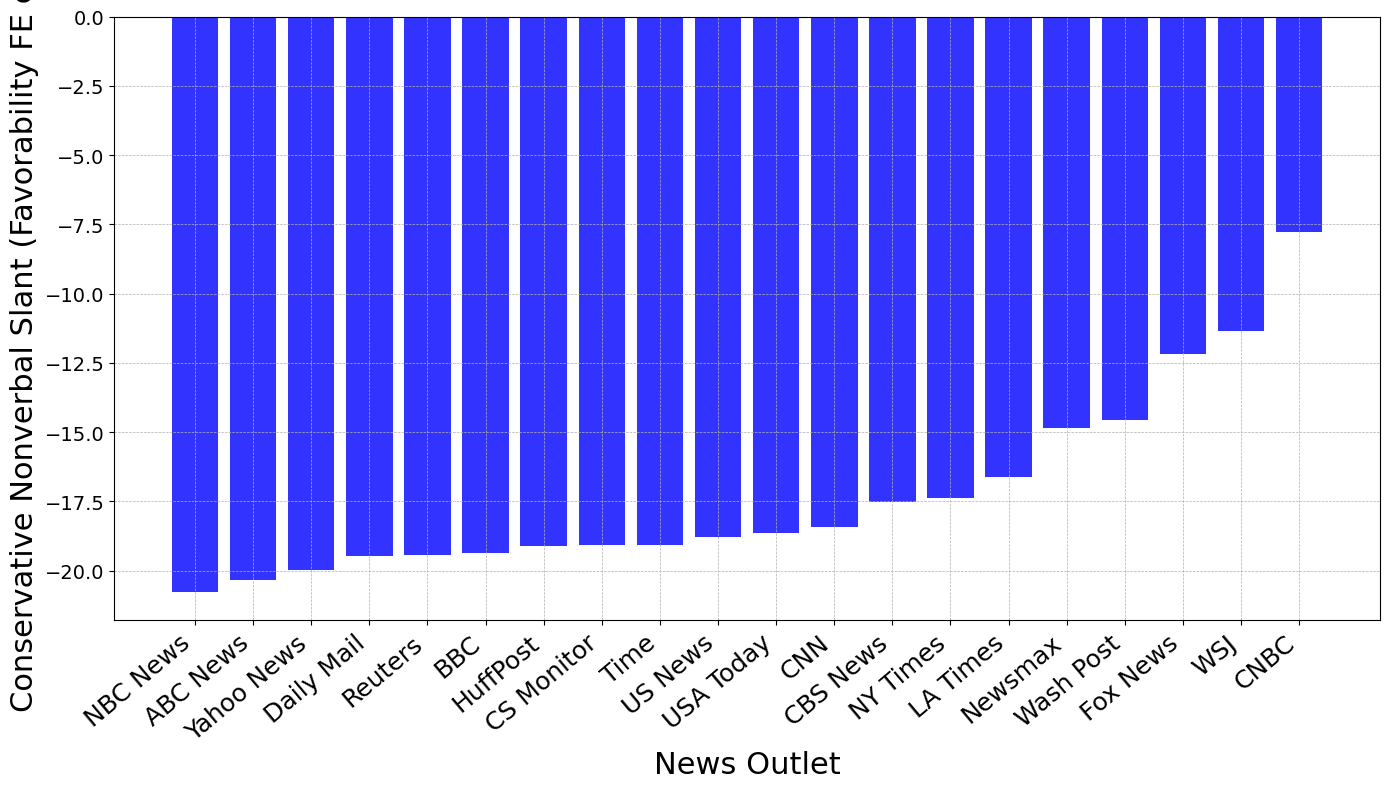

Running 1000 permutations for Fig_Harvard_Correlation_vs_FavSlant_F.png...


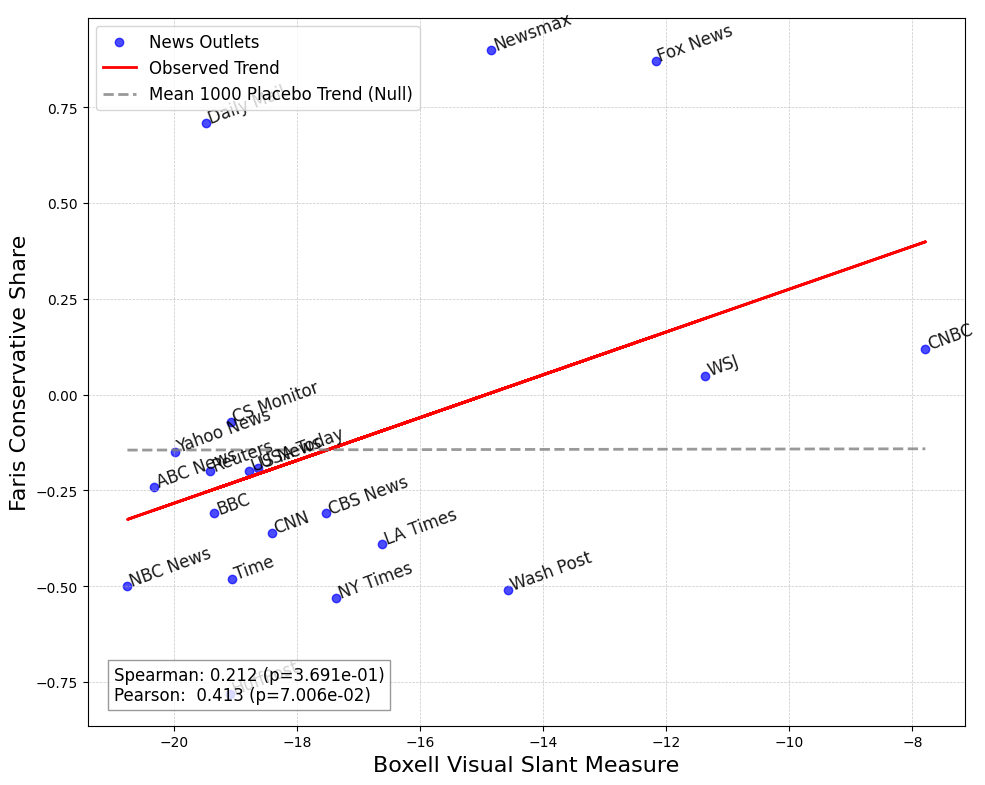

Running 1000 permutations for Fig_Allsides_Correlation_vs_FavSlant_F.png...


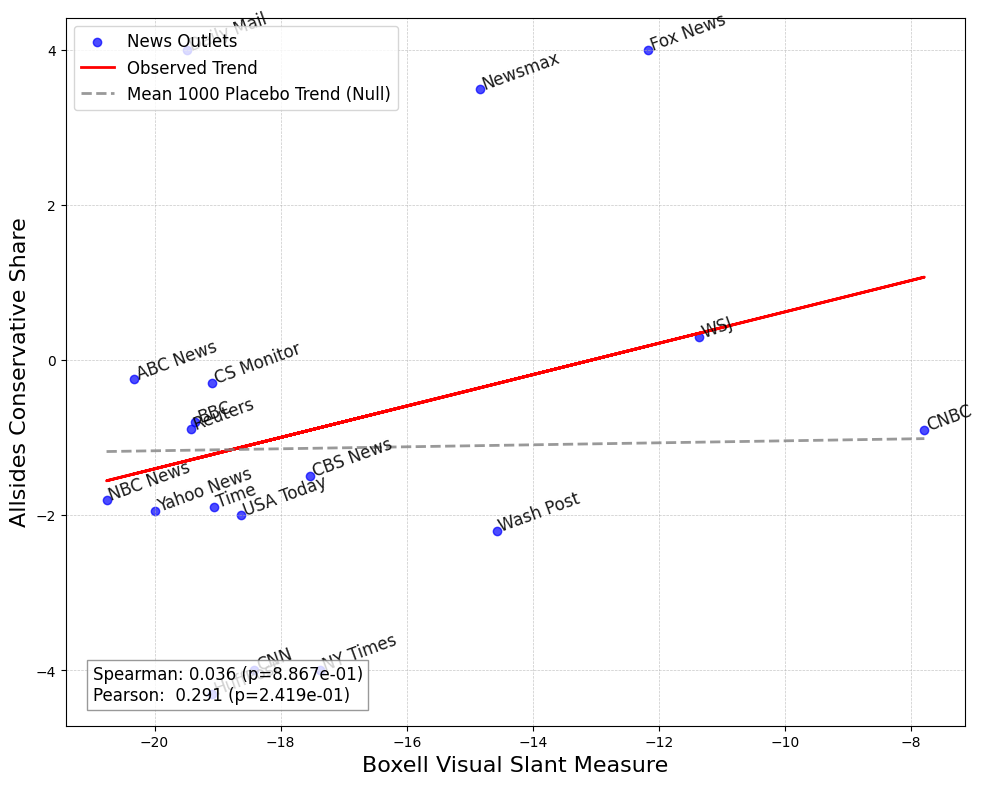

Running 1000 permutations for Fig_Flaxman_Correlation_vs_FavSlant_F.png...


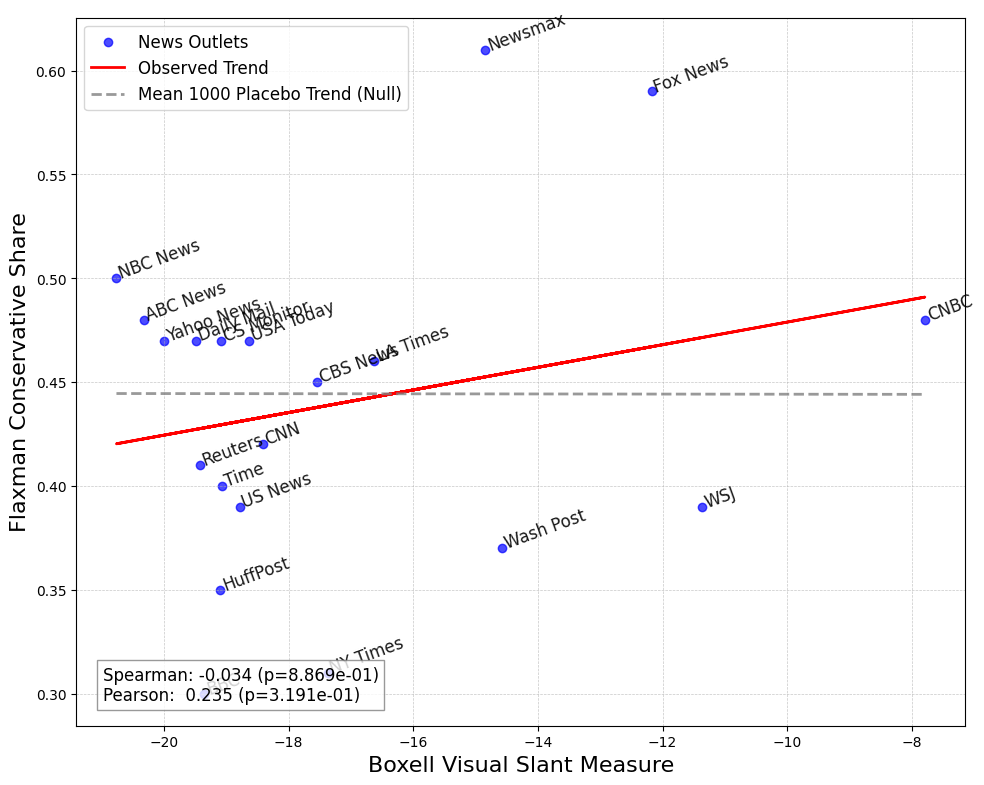

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import spearmanr, pearsonr

plt.style.use("default")

np.random.seed(42)
N_PERMUTATIONS = 1000

CSV_PATH = "data/Final_CSV_For_Analysis_with_Emotions.csv"


df = pd.read_csv(CSV_PATH).copy()

df = df[df["Real Person Side"].isin(["Republican", "Democratic"])].copy()

POLITICIAN_COL = "Top1_Person"
OUTLET_COL = "News Center"

news_center_affiliations = {
    'www.bbc.com': 'Democratic', 'www.nytimes.com': 'Democratic', 'www.huffpost.com': 'Democratic',
    'www.washingtonpost.com': 'Democratic', 'www.wsj.com': 'Republican', 'www.cnn.com': 'Democratic',
    'www.cbsnews.com': 'Democratic', 'www.latimes.com': 'Neutral', 'www.dailymail.co.uk': 'Republican',
    'abcnews.go.com': 'Democratic', 'www.nbcnews.com': 'Democratic', 'www.foxnews.com': 'Republican',
    'www.newsmax.com': 'Republican', 'www.usnews.com': 'Neutral', 'time.com': 'Democratic',
    'www.reuters.com': 'Neutral', 'news.yahoo.com': 'Neutral', 'www.usatoday.com': 'Neutral',
    'www.cnbc.com': 'Democratic', 'www.csmonitor.com': 'Neutral'
}

short_names = {
    'www.bbc.com': 'BBC', 'www.nytimes.com': 'NY Times', 'www.huffpost.com': 'HuffPost',
    'www.washingtonpost.com': 'Wash Post', 'www.wsj.com': 'WSJ', 'www.cnn.com': 'CNN',
    'www.cbsnews.com': 'CBS News', 'www.latimes.com': 'LA Times', 'www.dailymail.co.uk': 'Daily Mail',
    'abcnews.go.com': 'ABC News', 'www.nbcnews.com': 'NBC News', 'www.foxnews.com': 'Fox News',
    'www.newsmax.com': 'Newsmax', 'www.usnews.com': 'US News', 'time.com': 'Time',
    'www.reuters.com': 'Reuters', 'news.yahoo.com': 'Yahoo News', 'www.usatoday.com': 'USA Today',
    'www.cnbc.com': 'CNBC', 'www.csmonitor.com': 'CS Monitor'
}

harvard = {
    'www.bbc.com': -0.31, 'www.nytimes.com': -0.53, 'www.huffpost.com': -0.78, 'www.washingtonpost.com': -0.51,
    'www.wsj.com': 0.05, 'www.usnews.com': -0.20, 'time.com': -0.48, 'www.reuters.com': -0.20, 'www.cnn.com': -0.36,
    'www.cbsnews.com': -0.31, 'www.latimes.com': -0.39, 'news.yahoo.com': -0.15, 'www.usatoday.com': -0.19,
    'www.dailymail.co.uk': 0.71, 'www.cnbc.com': 0.12, 'www.csmonitor.com': -0.07, 'abcnews.go.com': -0.24,
    'www.nbcnews.com': -0.50, 'www.foxnews.com': 0.87, 'www.newsmax.com': 0.9
}

allsides = {
    'www.bbc.com': -0.8, 'www.nytimes.com': -4, 'www.huffpost.com': -4.3, 'www.washingtonpost.com': -2.2,
    'www.wsj.com': 0.3, 'time.com': -1.9, 'www.reuters.com': -0.89, 'www.cnn.com': -4, 'www.cbsnews.com': -1.5,
    'news.yahoo.com': -1.95, 'www.usatoday.com': -2, 'www.dailymail.co.uk': 4, 'www.cnbc.com': -0.9,
    'www.csmonitor.com': -0.3, 'abcnews.go.com': -0.24, 'www.nbcnews.com': -1.8, 'www.foxnews.com': 4,
    'www.newsmax.com': 3.5
}

other_paper = {
    'www.bbc.com': 0.30, 'www.nytimes.com': 0.31, 'www.huffpost.com': 0.35, 'www.washingtonpost.com': 0.37,
    'www.wsj.com': 0.39, 'www.usnews.com': 0.39, 'time.com': 0.40, 'www.reuters.com': 0.41, 'www.cnn.com': 0.42,
    'www.cbsnews.com': 0.45, 'www.latimes.com': 0.46, 'news.yahoo.com': 0.47, 'www.usatoday.com': 0.47,
    'www.dailymail.co.uk': 0.47, 'www.cnbc.com': 0.48, 'www.csmonitor.com': 0.47, 'abcnews.go.com': 0.48,
    'www.nbcnews.com': 0.50, 'www.foxnews.com': 0.59, 'www.newsmax.com': 0.61
}

df["fav"] = (
    df["emotion_happy"]
    - (
        df["emotion_angry"]
        + df["emotion_disgust"]
        + df["emotion_fear"]
        + df["emotion_sad"]
        + df["emotion_surprise"]
    )
)

df["is_rep"] = (df["Real Person Side"] == "Republican").astype(int)

df_fe = df.rename(columns={
    OUTLET_COL: "NewsCenter",
    POLITICIAN_COL: "Politician"
})

df_fe = df_fe.dropna(subset=["Politician", "NewsCenter"])

formula = "fav ~  C(NewsCenter):is_rep"
formula = "fav ~ C(Politician) + C(NewsCenter) + C(NewsCenter):is_rep"

model = smf.ols(formula, data=df_fe).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_fe["NewsCenter"]}
)

print(model.summary())

coefs = model.params
rows = []

for name, value in coefs.items():
    if name.startswith("C(NewsCenter)[") and ":is_rep" in name:
        try:
            start = name.index("[") + 1
            end = name.index("]", start)
            inner = name[start:end]
            if inner.startswith("T."):
                outlet = inner[2:]
            else:
                outlet = inner
        except ValueError:
            continue
        rows.append({"News Center": outlet, "delta_hat": value})

delta_df = pd.DataFrame(rows)

print("\nRaw delta_df from regression (favorability):")
print(delta_df)


def run_permutation_slopes_fe(conservative_share, valid_outlets, r_observed):
    politician_affiliations = df_fe[["Politician", "Real Person Side"]].drop_duplicates()

    null_slopes = []
    null_intercepts = []
    null_correlations = []

    y_fixed = np.array([conservative_share[nc] for nc in valid_outlets], dtype=float)

    for _ in range(N_PERMUTATIONS):
        shuffled_labels = politician_affiliations["Real Person Side"].sample(frac=1, replace=False).values
        politician_map = dict(zip(politician_affiliations["Politician"], shuffled_labels))

        df_permuted = df_fe.copy()
        df_permuted["Permuted Side"] = df_permuted["Politician"].map(politician_map)
        df_permuted["is_rep"] = (df_permuted["Permuted Side"] == "Republican").astype(int)

        model_perm = smf.ols(formula, data=df_permuted).fit(
            cov_type="cluster",
            cov_kwds={"groups": df_permuted["NewsCenter"]}
        )

        coefs_perm = model_perm.params
        rows_perm = []

        for name, value in coefs_perm.items():
            if name.startswith("C(NewsCenter)[") and ":is_rep" in name:
                try:
                    start = name.index("[") + 1
                    end = name.index("]", start)
                    inner = name[start:end]
                    if inner.startswith("T."):
                        outlet = inner[2:]
                    else:
                        outlet = inner
                except ValueError:
                    continue
                rows_perm.append({"News Center": outlet, "delta_hat": value})

        delta_perm_df = pd.DataFrame(rows_perm)

        x_perm = np.array(
            [delta_perm_df.loc[delta_perm_df["News Center"] == nc, "delta_hat"].iloc[0]
             for nc in valid_outlets],
            dtype=float
        )

        r_perm, _ = spearmanr(x_perm, y_fixed)
        null_correlations.append(r_perm)

        x_perm_with_const = sm.add_constant(x_perm)
        reg_perm = sm.OLS(y_fixed, x_perm_with_const).fit()
        null_intercepts.append(float(reg_perm.params[0]))
        null_slopes.append(float(reg_perm.params[1]))

    null_correlations = np.array(null_correlations)
    p_value = (np.sum(np.abs(null_correlations) >= np.abs(r_observed)) + 1) / (N_PERMUTATIONS + 1)

    return p_value, float(np.mean(null_slopes)), float(np.mean(null_intercepts))


delta_bar = delta_df[delta_df["News Center"].isin(short_names.keys())].copy()
delta_bar = delta_bar.sort_values("delta_hat", ascending=True)

if not delta_bar.empty:
    fig, ax = plt.subplots(figsize=(14, 8))

    bar_colors = ["red" if v > 0 else "blue" for v in delta_bar["delta_hat"]]
    ax.bar(delta_bar["News Center"], delta_bar["delta_hat"], color=bar_colors, alpha=0.8)

    ax.set_xlabel("News Outlet", fontsize=22)
    ax.set_ylabel("Conservative Nonverbal Slant (Favorability FE coef)", fontsize=22)
    ax.set_xticks(range(len(delta_bar["News Center"])))
    ax.set_xticklabels(
        [short_names[nc] for nc in delta_bar["News Center"]],
        ha="right", rotation=40, fontsize=18
    )
    ax.tick_params(axis="y", labelsize=14)
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)
    fig.tight_layout()
    fig.savefig("Fig_fav_FE_slant.png", dpi=100)
    plt.show()
else:
    print("No outlets in delta_df matched short_names; bar plot skipped.")


def plot_and_save_regression_with_correlation(conservative_share, conservative_label, filename):
    valid_outlets = [nc for nc in delta_df["News Center"] if nc in conservative_share]

    if len(valid_outlets) == 0:
        print(f"No overlap between FE outlets and {conservative_label} – skipping.")
        return

    y = np.array([conservative_share[nc] for nc in valid_outlets], dtype=float)
    x = np.array(
        [delta_df.loc[delta_df["News Center"] == nc, "delta_hat"].iloc[0]
         for nc in valid_outlets],
        dtype=float
    )

    spearman_corr, spearman_p_value = spearmanr(x, y)
    pearson_corr, pearson_p_value = pearsonr(x, y)

    x_with_const = sm.add_constant(x)
    reg = sm.OLS(y, x_with_const).fit()
    intercept = float(reg.params[0])
    slope = float(reg.params[1])

    print(f"Running {N_PERMUTATIONS} permutations for {filename}...")
    p_val_perm, mean_placebo_slope, mean_placebo_intercept = run_permutation_slopes_fe(
        conservative_share, valid_outlets, spearman_corr
    )

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(x, y, color="blue", alpha=0.7, label="News Outlets")
    ax.plot(x, intercept + slope * x, color='red', linestyle="-", linewidth=2, label="Observed Trend")

    x_range = np.linspace(float(np.min(x)), float(np.max(x)), 100)
    ax.plot(
        x_range,
        mean_placebo_intercept + mean_placebo_slope * x_range,
        color="gray",
        linestyle="--",
        linewidth=2,
        alpha=0.8,
        label=f"Mean {N_PERMUTATIONS} Placebo Trend (Null)"
    )

    labels = [short_names.get(nc, nc) for nc in valid_outlets]
    for i, label in enumerate(labels):
        ax.annotate(label, (x[i], y[i]), fontsize=12, alpha=0.9, rotation=20)

    stats_text = (
        f"Spearman: {spearman_corr:.3f} (p={spearman_p_value:.3e})\n"
        f"Pearson:  {pearson_corr:.3f} (p={pearson_p_value:.3e})"
    )

    ax.text(
        0.03, 0.03, stats_text,
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment="bottom",
        horizontalalignment="left",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
    )

    ax.set_xlabel("Boxell Visual Slant Measure", fontsize=16)
    ax.set_ylabel(conservative_label, fontsize=16)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
    ax.legend(loc="upper left", fontsize=12)
    plt.tight_layout()
    plt.savefig(filename, dpi=70)
    plt.show()
    plt.close(fig)


plot_and_save_regression_with_correlation(harvard, "Faris Conservative Share", "Fig_Harvard_Correlation_vs_FavSlant_F.png")
plot_and_save_regression_with_correlation(allsides, "Allsides Conservative Share", "Fig_Allsides_Correlation_vs_FavSlant_F.png")
plot_and_save_regression_with_correlation(other_paper, "Flaxman Conservative Share", "Fig_Flaxman_Correlation_vs_FavSlant_F.png")